# Figure 4 — HSP90 chaperone buffering
| Panel | Content |
|---|---|
| 4A | HSP90i abundance measurements per protein |
| 4B | Fractional change in standardised abundance |
| 4C | Buffering classes by domain context |
| 4D/S4A | Score violins with class composition |
| 4E | Buffering classes on the kinase fold |
| 4F/S4C | Buffering vs predictors |
| 4G | Buffering by activity class |
| S4B | Per-protein univariate importance |

In [1]:
import os, re, subprocess, shutil
from pathlib import Path
from typing import Iterable, Mapping, Sequence
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.patches import Patch
from PIL import Image
import svgutils.compose as sc

pd.set_option('display.max_columns', 100)


In [2]:
PROJECT_ROOT = Path(".").resolve()
DATA = PROJECT_ROOT / "data"
OUTPUT = PROJECT_ROOT / "Main5_HSP90_outputs"
ANNOTATED_COMBINED = "Supplementary_Table_2.tsv"

SCORE_WT_REL = "average score"
SCORE_ABS = "intercept_0_standard-adjusted score"
DN_ORDER = ["araf","braf","craf","egfr","erbb2","met","ret",
            "kras","mras","sos1","sos2","shp2","grb2","ksr1","ksr2"]
HSP90_ORDER = ["craf","araf","ret","ksr2","egfr","met","braf","mek2","mek1"]
PROTEIN_KEYS = DN_ORDER + [p for p in HSP90_ORDER if p not in DN_ORDER]
HSP90I_PROTEINS = ["araf","braf","craf","egfr","ksr2","mek1","mek2","met","ret","sos2"]

BASELINE_TREATMENTS = {"No_treatment", "DMSO"}
_DISPLAY_OVERRIDES = {"met":"HGFR","shp2":"SHP2","kras":"KRAS","mras":"MRAS"}

PYMOL_BIN = Path("/vol1/home/jjsimon/.local/bin/pymol")
PYMOL_FETCH_CACHE = DATA / "structures" / "pymol_fetch_cache"
FIG = OUTPUT
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 170)


# ---------------------------------------------------------------------------
# Palettes
# ---------------------------------------------------------------------------
DEPENDENCE_COLORS = {
    "High WT HSP90 dependence":     "#6e6e6e",
    "Moderate WT HSP90 dependence": "#6e6e6e",
    "Low WT HSP90 dependence":      "#6e6e6e",
    "Inverse WT\nHSP90 dependence": "#6e6e6e",
}

# VARIANT_TYPE_COLORS = {"missense":"#6A4C93","deletion":"#0E8F86","nonsense":"#B5651D"}
VARIANT_TYPE_COLORS = {"missense":"#6ABBA8","deletion":"#9B7DB8","nonsense":"#D65F4E"}
# BUFFERING_COLORS = {"Buffered":"#CC9A3A","Poorly buffered":"#9E2B3E","WT-like or high":"#237A54"}
BUFFERING_COLORS = {"Buffered":"#bd2c2c","Poorly buffered":"#d9892d","WT-like or high":"#3a6fb5"}
# STATUS_COLORS = {"strong": "#33507A", "weak": "#6E8FB0","non": "#8FADC7", "unknown": "#A0A0A0"}
STATUS_COLORS = {"strong": "#4F7570", "weak": "#8BB39A","non": "#D9BD80", "unknown": "#B5B5B5"}

BUFFERING_COLORS = {
    "Buffered": "#bd2c2c",
    "Poorly buffered": "#d9892d",
    "WT-like or high": "#3a6fb5",
}

BUFFERING_ORDER = ["Buffered", "Poorly buffered", "WT-like or high"]
BUFFERING_STACK_ORDER = ["WT-like or high", "Buffered", "Poorly buffered"]
BUFFERING_CMAPS = {"Buffered": "Reds", "Poorly buffered": "Oranges",
                   "WT-like or high": "Blues"}
ACTIVITY_COLORS = {
    "DN": "#C0392B",
    "low": "#26A69A",
    "wt-like": "#F4E04D",
    "high": "#E64A19",
}
ACTIVITY_ORDER = ["DN", "low", "wt-like", "high"]
ACTIVITY_GROUP_ORDER = ["High", "WT-like", "Low", "DN"]
ACTIVITY_GROUP_COLOR = {
    "High": "#E64A19", "WT-like": "#F4E04D", "Low": "#26A69A", "DN": "#C0392B",
}
MIN_N_PER_PROTEIN = 10
DB_COLORS = {"gnomAD": "#3571b6", "AoU": "#b67a35", "GENIE": "#4f8f4f"}
PROTEIN_SPHERE_COLOR = {
    "araf":  (0.85, 0.65, 0.10),   # mustard
    "braf":  (0.10, 0.28, 0.65),   # deep blue
    "craf":  (0.25, 0.55, 0.85),   # cornflower
    "egfr":  (0.70, 0.10, 0.15),   # ruby
    "erbb2": (0.65, 0.08, 0.12),   # maroon
    "kras":  (0.90, 0.45, 0.05),   # dark orange
    "met":   (0.55, 0.35, 0.10),   # bronze
    "mras":  (0.85, 0.50, 0.10),   # amber
    "ret":   (0.45, 0.05, 0.45),   # dark magenta
    "shp2":  (0.15, 0.60, 0.30),   # forest green
    "sos1":  (0.50, 0.05, 0.65),   # purple
    "sos2":  (0.05, 0.55, 0.45),   # teal
}
STRUCT_CARTOON_COLOR = "gray80"
STRUCT_PARTNER_COLORS = ("skyblue", "wheat", "lightpink")
# VARIANT_TYPE_COLORS = {
#     "missense": "#2166ac",   # blue
#     "deletion": "#1b7837",   # green
#     "nonsense": "#762a83",   # purple
# }
VARIANT_TYPE_ORDER = ["missense", "deletion", "nonsense"]
# VARIANT_CATEGORY_COLORS = {
#     "missense": "#2166ac",       # blue
#     "3nt deletion": "#1b7837",   # green
#     "nonsense": "#762a83",       # purple
#     "frameshift": "#b2182b",     # red
#     "other": "#8c8c8c",          # grey
# }
VARIANT_CATEGORY_ORDER = ["missense", "3nt deletion", "nonsense", "frameshift",
                          "other"]
ONTOLOGY_COLOR_B = "#d97b1f"      # orange
ONTOLOGY_COLOR_AS = "#a64ca6"     # purple
ONTOLOGY_COLOR_I = "#3a6fb5"      # blue
ONTOLOGY_COLOR_NONE = "#ffffff"   # white -- unexplained
ONTOLOGY_NONE_EDGE = "#999999"
ONTOLOGY_BUCKET_ORDER = ["B_only", "AS_only", "I_only", "B_I", "AS_I", "none"]
ONTOLOGY_BUCKET_STYLE: dict[str, tuple] = {
    "B_only":  (ONTOLOGY_COLOR_B, None, None),
    "AS_only": (ONTOLOGY_COLOR_AS, None, None),
    "I_only":  (ONTOLOGY_COLOR_I, None, None),
    "B_I":     (ONTOLOGY_COLOR_B, ONTOLOGY_COLOR_I, "////"),
    "AS_I":    (ONTOLOGY_COLOR_AS, ONTOLOGY_COLOR_I, "////"),
    "none":    (ONTOLOGY_COLOR_NONE, None, None),
}
ONTOLOGY_BUCKET_LABELS = {
    "B_only": "Buried (B)", "AS_only": "Active site (AS)",
    "I_only": "Interface (I)", "B_I": "B + I", "AS_I": "AS + I",
    "none": "Other",
}
ONTOLOGY_LEGEND_ROWS = [["B_only", "AS_only", "I_only", "none"],
                        ["B_I", "AS_I"]]
# ---------------------------------------------------------------------------
# Style
# ---------------------------------------------------------------------------
def fix_svg_pattern_order(svg_path):
    svg_path = Path(svg_path)
    content = svg_path.read_text()
    defs_blocks = re.findall(r'<defs>.*?</defs>', content, re.S)
    pattern_blocks = [b for b in defs_blocks if '<pattern' in b]
    if not pattern_blocks:
        return
    for block in pattern_blocks:
        content = content.replace(block, '', 1)
    insert_at = re.search(r'<svg[^>]*>', content).end()
    content = content[:insert_at] + '\n' + '\n'.join(pattern_blocks) + content[insert_at:]
    svg_path.write_text(content)
# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------


SCORES_RECOVERED = OUTPUT / "scoring" / "scores_masterframe_recovered.tsv"
SCORES_REANNOTATED = OUTPUT / "scoring" / "scores_reannotated.tsv"
ANNOTATED_COMBINED = OUTPUT / "annotated_combined.tsv"
CONTROL_BARCODE_SCORES = OUTPUT / "scoring" / "control_barcode_scores.tsv"
DN_THRESHOLDS = OUTPUT / "scoring" / "dn_thresholds_recomputed.tsv"
EV_CUTOFFS = DATA / "dn_cutoffs_empty_vector.tsv"
INTERACTIONS_AUGMENTED = OUTPUT / "dn" / "interactions_curated_augmented.tsv"
POPULATION_HGVSP = OUTPUT / "population_data_hgvsp.tsv"
STRUCTURE_ANNOTATIONS = OUTPUT / "structure_annotations.tsv"
AF_STRUCTURES = (PROJECT_ROOT / "data" / "inputs" / "annotations" / "AF_MAPK_structures")
SPURS_DDG = PROJECT_ROOT / "data" / "inputs" / "spurs_ddg_all_proteins.tsv"
PHYLOP_PER_POSITION = OUTPUT / "dn" / "phylop_per_position.tsv"
KINASE_JSD = OUTPUT / "hsp90" / "kinase_jsd_per_position.tsv"
TRANSFERRED_CONTACTS = OUTPUT / "hsp90" / "transferred_contacts.tsv"
KINASE_MOTIFS = OUTPUT / "hsp90" / "kinase_motif_assignments.tsv"
GENIE_JOINED = OUTPUT / "clinical" / "activity_vs_genie_joined.tsv"
REFERENCE_FASTA = DATA / "reference_protein_sequences.fasta"
PROTEIN_ACCESSIONS = PROJECT_ROOT / "config" / "protein_accessions.yaml"
def save_figure(
    fig: Figure,
    stem: str | Path,
    *,
    formats: Sequence[str] = ("pdf", "svg", "png"),
    tight: bool = True,
) -> list[Path]:
    stem = Path(stem)
    stem.parent.mkdir(parents=True, exist_ok=True)
    kw = {"bbox_inches": "tight"} if tight else {}
    written = []
    for ext in formats:
        p = stem.with_suffix(f".{ext}")
        fig.savefig(p, **kw)
        if ext == "svg":
            fix_svg_pattern_order(p)
        written.append(p)
    return written

In [3]:
COLS = ["protein", "library", "assay", "assay_treatment", "variant",
        "Mutation Type", "Wild Type Residue", "Mutation", "Position",
        SCORE_WT_REL, SCORE_ABS, "classification_2.5pct", "DN_EV",
        "domain", "relative_sasa", "ddG_SPURS", "jsd_conservation",
        "phylop_vert", "kinase_motif", "active_site",
        "interface_pdb_curated", "at_hsp90_unfolded", "at_hsp90_folded",
        "at_cdc37", "chaperone_contact_resolved",
        "client_status_literature", "intercept_0_std_adj_score_1", "intercept_0_std_adj_score_2", 
        "intercept_0_std_adj_score_3"
       ]

def protein_label(protein: str) -> str:
    key = str(protein).strip().lower()
    suffix = ""
    if key.endswith("_cterm"):
        key, suffix = key[:-6], " (C)"
    elif key.endswith("_nterm"):
        key, suffix = key[:-6], " (N)"
    elif key.endswith("_ss"):
        key, suffix = key[:-3], " (serum-starved)"
    elif key.endswith("_ciar"):
        key, suffix = key[:-5], " (CIAR)"
    return _DISPLAY_OVERRIDES.get(key, key.upper()) + suffix
    
def protein_labels(proteins: Iterable[str]) -> list[str]:
    return [protein_label(p) for p in proteins]
    
def stars_4tier(p: float) -> str:
    if p is None or not np.isfinite(p):
        return ""
    return ("****" if p < 1e-4 else "***" if p < 1e-3 else
            "**" if p < 1e-2 else "*" if p < 0.05 else "ns")

def stars_4tier_ns(p: float) -> str:
    if p is None or not np.isfinite(p):
        return "n.s."
    return ("****" if p < 1e-4 else "***" if p < 1e-3 else
            "**" if p < 1e-2 else "*" if p < 0.05 else "n.s.")

def apply_style(*, base_fontsize: float = 8.0) -> None:
    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "pdf.fonttype": 42, "svg.fonttype": "none",
        "font.size": base_fontsize, "axes.labelsize": base_fontsize,
        "axes.titlesize": base_fontsize + 1,
        "xtick.labelsize": base_fontsize - 1,
        "ytick.labelsize": base_fontsize - 1,
        "legend.fontsize": base_fontsize - 1,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.linewidth": 0.5,
        "xtick.major.width": 0.5, "ytick.major.width": 0.6,
        "figure.dpi": 200, "savefig.dpi": 300,
        "svg.fonttype": "none",
        "savefig.transparent": True
    })
    
def load_scored():
    return pd.read_csv(ANNOTATED_COMBINED, sep="\t", low_memory=False,
                       usecols=list(dict.fromkeys(COLS)))

def pair_abundance(ann, score_col, proteins=tuple(HSP90I_PROTEINS)):
    ab = ann[(ann.assay == "abundance") & ann.protein.isin(set(proteins))].copy()
    ctrl = ab[ab.assay_treatment.isin(BASELINE_TREATMENTS)].copy()
    hsp = ab[ab.assay_treatment == "HSP90i"]
    ctrl["_pref"] = (ctrl.assay_treatment == "DMSO").astype(int)
    ctrl = (ctrl.sort_values("_pref", ascending=False)
            .drop_duplicates(["protein", "library", "variant"]).drop(columns="_pref"))
    key = ["protein", "library", "variant"]
    out = ctrl.merge(hsp[key + [score_col]].rename(columns={score_col: "hsp90i_score"}),
                     on=key, how="inner")
    out = out.rename(columns={score_col: "ctrl_score",
                              "assay_treatment": "ctrl_treatment"})
    return out.dropna(subset=["ctrl_score", "hsp90i_score"]).reset_index(drop=True)

def syn_wt_low_threshold(ann, score_col):
    syn = ann[(ann["Mutation Type"] == "synonymous wild type")].dropna(subset=[score_col])
    return (syn.groupby(["library", "assay", "assay_treatment"])[score_col]
            .quantile(0.025).rename("threshold").reset_index())

def assign_buffering(paired, ann, score_col):
    thr = syn_wt_low_threshold(ann, score_col)
    ab = thr[thr.assay == "abundance"]
    ctrl_thr = (ab[ab.assay_treatment.isin(BASELINE_TREATMENTS)]
                .set_index(["library", "assay_treatment"])["threshold"])
    hsp_thr = ab[ab.assay_treatment == "HSP90i"].set_index("library")["threshold"]
    out = paired.copy()
    out["ctrl_threshold"] = pd.MultiIndex.from_arrays(
        [out.library, out.ctrl_treatment]).map(ctrl_thr)
    out["hsp90i_threshold"] = out.library.map(hsp_thr)
    ctrl_low = out.ctrl_score < out.ctrl_threshold
    hsp_low = out.hsp90i_score < out.hsp90i_threshold
    cls = pd.Series(np.nan, index=out.index, dtype=object)
    cls[(~ctrl_low) & hsp_low] = "Buffered"
    cls[ctrl_low & hsp_low] = "Poorly buffered"
    cls[(~ctrl_low) & (~hsp_low)] = "WT-like or high"
    out["buffering_class"] = cls
    return out

def activity_group(df):
    g = df["classification_2.5pct"].astype(object).copy()
    g[df["DN_EV"] == True] = "DN"   # noqa: E712
    return g

def bin_edges(col, n_bins):
    s = cohort[col].dropna()
    lo, hi = np.nanpercentile(s, X_CLIP_PCT)
    return np.linspace(lo, hi, n_bins + 1)

def binned(sub, col, edges):
    s = sub[[col, "cat"]].dropna()
    if s.empty:
        return pd.DataFrame()
    idx = np.digitize(s[col].to_numpy(), edges) - 1
    idx = np.clip(idx, 0, len(edges) - 2)
    s = s.assign(bin=idx)
    out = []
    for b, g in s.groupby("bin"):
        row = {"bin_center": (edges[b] + edges[b + 1]) / 2, "n": len(g)}
        for _k, key in CLASS_KEY.items():
            row[f"frac_{key}"] = float((g.cat == key).sum() / len(g))
        out.append(row)
    return pd.DataFrame(out).sort_values("bin_center")

def _parse_alignment_fasta(path):
    records, header, chunks = [], None, []
    with open(path) as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(chunks)))
                header = line[1:].split()[0]
                chunks = []
            else:
                chunks.append(line)
        if header is not None:
            records.append((header, "".join(chunks)))
    return records

def _load_cropped(path, pad=10, thresh=250):
    arr = np.array(Image.open(path).convert("RGB"))
    mask = np.any(arr < thresh, axis=-1)
    rows, cols = np.where(mask.any(axis=1))[0], np.where(mask.any(axis=0))[0]
    r0, r1 = max(rows.min() - pad, 0), min(rows.max() + pad, arr.shape[0] - 1)
    c0, c1 = max(cols.min() - pad, 0), min(cols.max() + pad, arr.shape[1] - 1)
    return arr[r0:r1 + 1, c0:c1 + 1]

def _aspect_wh(arr):
    h, w = arr.shape[:2]
    return w / h

def _panel(ax, arr, label=None):
    ax.imshow(arr, aspect="equal")
    ax.axis("off")
    if label is not None:
        ax.text(-0.02, 1.0, label, transform=ax.transAxes,
                fontsize=PANEL_LETTER_FS, fontweight="bold",
                va="bottom", ha="left")

def _fig_rect(x_in, y_in, w_in, h_in):
    return [x_in / PAGE_W, y_in / PAGE_H, w_in / PAGE_W, h_in / PAGE_H]

def _vec(svg_path, x_in, y_in_top, h_in):
    el = sc.SVG(str(svg_path), fix_mpl=True)
    scale = (h_in * PT_PER_IN) / el.height
    el.scale(scale)
    el.move(x_in * PT_PER_IN, y_in_top * PT_PER_IN)
    return el, (el.width * scale) / PT_PER_IN

def _raster(arr, x_in, y_in_top, h_in, asp, tmp_path):
    Image.fromarray(arr).save(tmp_path)
    w_in = h_in * asp
    img = sc.Image(w_in * PT_PER_IN, h_in * PT_PER_IN, str(tmp_path))
    img.move(x_in * PT_PER_IN, y_in_top * PT_PER_IN)
    return img

def _label(text, x_in, y_in_top, *, size, weight="bold", color="black",
          anchor="start"):
    return sc.Text(text, x_in * PT_PER_IN, y_in_top * PT_PER_IN, size=size,
                   weight=weight, color=color, anchor=anchor,
                   font="Arial")

In [4]:
Replicate_scores = load_scored()
print(f"loaded {len(Replicate_scores):,} rows")
_paired = pair_abundance(Replicate_scores, SCORE_WT_REL)
_paired = assign_buffering(_paired, Replicate_scores, SCORE_WT_REL)
_bc = _paired[["protein","library","variant","buffering_class"]].drop_duplicates(
    ["protein","library","variant"])
Replicate_scores = Replicate_scores.merge(_bc, on=["protein","library","variant"], how="left")
_m = (Replicate_scores.assay == "activity") & Replicate_scores.assay_treatment.isin(BASELINE_TREATMENTS)
Replicate_scores["activity_group"] = pd.Series(np.nan, index=Replicate_scores.index, dtype=object)
Replicate_scores.loc[_m, "activity_group"] = activity_group(Replicate_scores.loc[_m])
print(f"buffering_class: {Replicate_scores.buffering_class.notna().sum():,} rows filled")
paired_all = pair_abundance(Replicate_scores, SCORE_WT_REL)
paired_all = assign_buffering(paired_all, Replicate_scores, SCORE_WT_REL)
paired_md = paired_all[paired_all["Mutation Type"].isin(["missense", "deletion"])]
paired = paired_all[paired_all["Mutation Type"] == "missense"]
print(f"paired missense+deletion: {int(paired_md.buffering_class.notna().sum()):,}")
del _paired, _bc, _m

loaded 531,797 rows
buffering_class: 341,372 rows filled
paired missense+deletion: 93,003


## 4A — what was measured

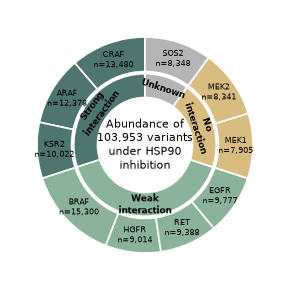

total = 103,953 variants across 10 proteins


,CRAF,ARAF,KSR2,BRAF,HGFR,RET,EGFR,MEK1,MEK2,SOS2
variants,13480,12378,10022,15300,9014,9388,9777,7905,8341,8348


In [6]:
def plot_donut(
    outer_sizes: Sequence[float],
    outer_colors: Sequence,
    outer_labels: Sequence[str],
    *,
    inner_sizes: Sequence[float] = (),
    inner_colors: Sequence = (),
    inner_labels: Sequence[str] = (),
    figsize: tuple[float, float] = (3.5, 3.5),
    outer_width: float = 0.32,
    outer_label_r: float = 0.84,
    inner_radius: float = 0.66,
    inner_width: float = 0.22,
    edge_lw: float = 1.2,
    startangle: float = 90.0,
    center_label: str = "",
    inner_rotate: bool = True,
    inner_bold: bool = True,
    fs: Mapping[str, float] | None = None,
) -> tuple[Figure, Axes]:
    F = {"outer": 12.0, "inner": 12.0, "center": 17.0}
    F.update(fs or {})
    fig, ax = plt.subplots(figsize=figsize)
    outer_wedges, _ = ax.pie(
        list(outer_sizes), radius=1.0, startangle=startangle,
        colors=list(outer_colors),
        wedgeprops={"width": outer_width, "edgecolor": "white",
                    "linewidth": edge_lw})
    inner_wedges = []
    if len(inner_sizes):
        inner_wedges, _ = ax.pie(
            list(inner_sizes), radius=inner_radius, startangle=startangle,
            colors=list(inner_colors),
            wedgeprops={"width": inner_width, "edgecolor": "white",
                        "linewidth": edge_lw})
    for w, label in zip(outer_wedges, outer_labels):
        if not label:
            continue
        a = np.deg2rad((w.theta1 + w.theta2) / 2)
        ax.text(outer_label_r * np.cos(a), outer_label_r * np.sin(a), label,
                ha="center", va="center", fontsize=F["outer"], color="black")
    r_in = inner_radius - inner_width / 2
    for w, label in zip(inner_wedges, inner_labels):
        if not label:
            continue
        angle = (w.theta1 + w.theta2) / 2
        a = np.deg2rad(angle)
        rot = 0.0
        if inner_rotate:
            # Tangential = radial angle - 90 deg, normalised to [-180, 180],
            # then flipped 180 deg in the lower half so text stays upright.
            rot = ((angle - 90) + 180) % 360 - 180
            if rot > 90 or rot < -90:
                rot += 180
        ax.text(r_in * np.cos(a), r_in * np.sin(a), label, ha="center",
                va="center", fontsize=F["inner"],
                fontweight="bold" if inner_bold else "normal", color="black",
                rotation=rot, rotation_mode="anchor")
    if center_label:
        ax.text(0, 0, center_label, ha="center", va="center",
                fontsize=F["center"], color="black")
    ax.set(aspect="equal")
    fig.tight_layout()
    return fig, ax

# === VISUAL CONFIG ===
FONT_SIZES = {"axis": 6.0, "tick": 6.0, "legend": 6.0, "title": 6.0, "annot": 6}
LINE_WIDTHS = {"axes": 0.5, "plot": 1.2}
# =====================
COUNTED_TYPES = {"missense", "synonymous wild type", "deletion", "nonsense",
                 "wild type"}
hsp_ab = Replicate_scores[(Replicate_scores.assay == "abundance")
                          & (Replicate_scores.assay_treatment == "HSP90i")
                          & Replicate_scores["Mutation Type"].isin(COUNTED_TYPES)]
counts = hsp_ab.groupby("protein").size().to_dict()
HSP90_CLIENT_STATUS = {
    "craf": "strong", "araf": "strong", "ksr2": "strong",
    "braf": "weak", "met": "weak", "ret": "weak", "egfr": "weak",
    "mek1": "non", "mek2": "non",
    "sos2": "unknown",
}
STATUS_ORDER = ["strong", "weak", "non", "unknown"]
STATUS_LABELS = {"strong": "Strong\ninteraction", "weak": "Weak\ninteraction",
                 "non": "No\ninteraction", "unknown": "Unknown"}
# Reserved teal/sage/wheat/grey palette: deliberately clear of the dependence
# palette and of the canonical buffering red/orange/blue, so client status is
# never read as a buffering result.
grouped = {s: [p for p, st in HSP90_CLIENT_STATUS.items() if st == s]
           for s in STATUS_ORDER}
inner_sizes = [len(grouped[s]) for s in STATUS_ORDER]
inner_colors = [STATUS_COLORS[s] for s in STATUS_ORDER]
inner_labels = [STATUS_LABELS[s] for s in STATUS_ORDER]
outer_sizes, outer_colors, outer_labels = [], [], []
for status in STATUS_ORDER:
    prots = grouped[status]
    if not prots:
        continue
    total = sum(counts[p] for p in prots) or 1
    for i, p in enumerate(prots):
        outer_sizes.append(len(prots) * counts[p] / total)
        outer_colors.append(STATUS_COLORS[status])
        outer_labels.append(f"{protein_label(p)}\nn={counts[p]:,}")
total_n = sum(counts[p] for p in HSP90_CLIENT_STATUS)
fig, _ = plot_donut(
    outer_sizes, outer_colors, outer_labels,
    inner_sizes=inner_sizes, inner_colors=inner_colors,
    inner_labels=inner_labels,
    figsize=(3, 3),
    fs={"outer": 6.0, "inner": 6.5, "center": 8},
    center_label=f"Abundance of\n{total_n:,} variants\nunder HSP90\ninhibition")
save_figure(fig, FIG / "5a_hsp90i_measurement_wheel")
plt.show()
print(f"total = {total_n:,} variants across {len(HSP90_CLIENT_STATUS)} proteins")
display(pd.Series({protein_label(p): counts[p]
                   for p in HSP90_CLIENT_STATUS}, name="variants").to_frame().T)

## 4B — dependence: fractional change in abundance

paired on the absolute scale: 110,360 variants


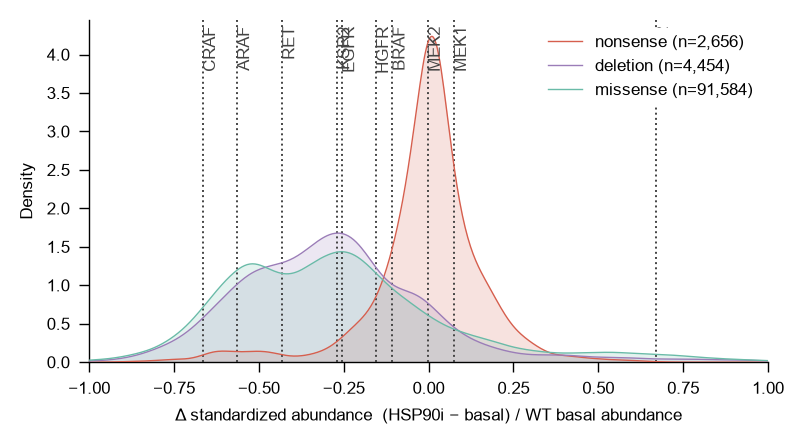

,n,median,WT
protein,,,
craf,11810,-0.605,-0.665
araf,10818,-0.542,-0.565
ret,8552,-0.461,-0.432
ksr2,8709,-0.243,-0.270
egfr,8847,-0.297,-0.255
met,8205,-0.283,-0.155
braf,13050,-0.181,-0.107
mek2,7307,-0.114,-0.003
mek1,6880,0.089,0.074


In [8]:
plt.rcParams.update({
    "font.size": 6, "axes.labelsize": 6, "axes.titlesize": 6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "legend.title_fontsize": 6,
    "axes.linewidth": 0.5, "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "lines.linewidth": 0.5, "patch.linewidth": 0.5,
    "figure.dpi": 200, "savefig.transparent": True,
        "svg.fonttype": "none",
        "savefig.transparent": True
})

def plot_density_panel(
    series: Mapping[str, Sequence[float]],
    *,
    colors: Mapping[str, str],
    marker_lines: Mapping[str, float] = {},
    xlabel: str = "",
    ylabel: str = "Density",
    xlim: tuple[float, float] | None = None,
    figsize: tuple[float, float] = (11.0, 5.0),
    bw_adjust: float = 1.0,
    grid_n: int = 512,
    fill_alpha: float = 0.18,
    lw: float = 0.5,
    ref_line: float | None = None,
    marker_color: str = "#444444",
    marker_fs: float = 9.0,
    n_label_rows: int = 4,
    x_percent: bool = False,
    legend_fmt: str = "{label} (n={n:,})",
    fs: Mapping[str, float] | None = None,
) -> tuple[Figure, Axes]:
    from scipy import stats as _st
    F = {"axis": 12.0, "tick": 11.0, "legend": 11.0}
    F.update(fs or {})
    clean = {k: np.asarray([v for v in vals if np.isfinite(v)], dtype=float)
             for k, vals in series.items()}
    clean = {k: v for k, v in clean.items() if v.size > 1}
    if xlim is None:
        allv = np.concatenate(list(clean.values()))
        xlim = (float(np.nanpercentile(allv, 0.5)),
                float(np.nanpercentile(allv, 99.5)))

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    if ref_line is not None:
        ax.axvline(ref_line, ls=":", color="0.45", lw=0.7, zorder=1)

    grid = np.linspace(xlim[0], xlim[1], grid_n)
    for label, vals in clean.items():
        kde = _st.gaussian_kde(vals)
        kde.set_bandwidth(kde.factor * bw_adjust)
        y = kde(grid)
        col = colors.get(label, "#666666")
        ax.plot(grid, y, color=col, lw=lw, zorder=4,
                label=legend_fmt.format(label=label, n=int(vals.size)))
        ax.fill_between(grid, y, color=col, alpha=fill_alpha, lw=0, zorder=2)

    ax.set_xlim(*xlim)
    ax.set_ylim(bottom=0.0)
    top = ax.get_ylim()[1]

    for rank, (name, x) in enumerate(sorted(marker_lines.items(),
                                            key=lambda kv: kv[1])):
        if not np.isfinite(x):
            continue
        ax.axvline(x, ls=":", color=marker_color, lw=0.7, zorder=3)
        ax.text(x, top * 0.98, f" {name}", ha="left", va="top", fontsize=marker_fs,
                color=marker_color, rotation=90, zorder=5)

    if x_percent:
        ax.xaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _p: f"{v * 100:.0f}%"))

    ax.set_xlabel(xlabel, fontsize=F["axis"])
    ax.set_ylabel(ylabel, fontsize=F["axis"])
    ax.tick_params(labelsize=F["tick"])
    leg = ax.legend(frameon=True, fontsize=F["legend"], loc="upper right",
                    facecolor="white", edgecolor="none", framealpha=1.0)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
    for sp in ax.spines.values():
        sp.set_linewidth(0.5)

    fig.tight_layout()
    return fig, ax


# === VISUAL CONFIG ===
FONT_SIZES = {"axis": 6.0, "tick": 6.0, "legend": 6.0}
LINE_WIDTHS = {"axes": 0.5, "plot": 0.5}
# =====================

# Pair variants on the absolute scale
SCORE_ABS = "intercept_0_standard-adjusted score"
paired_abs = pair_abundance(Replicate_scores, SCORE_ABS)

# Fractional change normalised to each protein's WT control abundance
wt_ctrl = (paired_abs[paired_abs["Mutation Type"] == "wild type"]
           .groupby("protein").ctrl_score.mean())
paired_abs["wt_ctrl_score"] = paired_abs.protein.map(wt_ctrl)
paired_abs["frac_change"] = ((paired_abs.hsp90i_score - paired_abs.ctrl_score)
                             / paired_abs.wt_ctrl_score.replace(0, np.nan))
print(f"paired on the absolute scale: {len(paired_abs):,} variants")

# Split by variant type
TYPES = ["nonsense", "deletion", "missense"]
pa = paired_abs[paired_abs["Mutation Type"].isin(TYPES)]

# WT marker lines
wt_frac = (paired_abs[paired_abs["Mutation Type"] == "wild type"]
           .groupby("protein").frac_change.mean())
wt_lines = {protein_label(p): float(v) for p, v in wt_frac.items()
            if np.isfinite(v)}

# Plot
fig, _ = plot_density_panel(
    {t_: pa.loc[pa["Mutation Type"] == t_, "frac_change"].to_numpy()
     for t_ in TYPES},
    colors=VARIANT_TYPE_COLORS,
    marker_lines=wt_lines, ref_line=None, x_percent=False,
    xlim=(-1.0, 1.0),
    xlabel="Δ standardized abundance  (HSP90i − basal) / WT basal abundance",
    ylabel="Density",
    figsize=(4.0, 2.2),
    lw=0.5,
    marker_fs=6.0,
    fs=FONT_SIZES)

# Save and display
plt.rcParams["savefig.transparent"] = True
save_figure(fig, FIG / "5b_fractional_dependence", tight=False)
plt.show()

# Summary table
summ = (pa[pa["Mutation Type"] == "missense"].groupby("protein").frac_change
        .agg(n="size", median="median").round(3))
summ["WT"] = wt_frac.round(3)
display(summ.reindex([p for p in HSP90_ORDER if p in summ.index]))

## 4C — buffering is concentrated in kinase domains

paired missense+deletion with a buffering class: 93,003 of 96,038 (3.2% dropped as control-low / HSP90i-not-low)
   of which missense only (the factor-panel cohort): 91,584


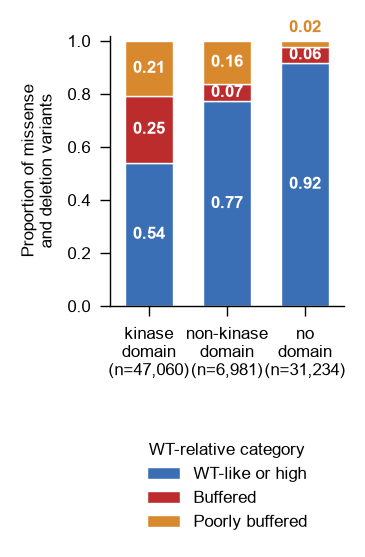

buffering_class,WT-like or high,Buffered,Poorly buffered
domain_grp,,,
kinase\ndomain,54.0,25.2,20.8
non-kinase\ndomain,77.2,6.7,16.2
no\ndomain,91.8,5.8,2.4


In [13]:
plt.rcParams.update({
    "font.size": 6, "axes.labelsize": 6, "axes.titlesize": 6,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "xtick.labelsize": 6, "ytick.labelsize": 6, "legend.fontsize": 6,
    "legend.title_fontsize": 6,
    "axes.linewidth": 0.5, "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "lines.linewidth": 0.5, "patch.linewidth": 0.5,
    "figure.dpi": 200, "savefig.transparent": True,
        "svg.fonttype": "none",
        "savefig.transparent": True
})

def fixed_pitch_bar_axes(
    n_bars: int,
    *,
    pitch_in: float = 0.95,
    axes_h_in: float = 3.40,
    left_in: float = 0.95,
    right_in: float = 0.30,
    bottom_in: float = 1.15,
    top_in: float = 0.50,
    legend_in: float = 0.0,
) -> tuple[Figure, Axes]:
    data_w = n_bars * pitch_in
    fig_w = left_in + data_w + right_in + legend_in
    fig_h = bottom_in + axes_h_in + top_in
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = fig.add_axes([left_in / fig_w, bottom_in / fig_h,
                       data_w / fig_w, axes_h_in / fig_h])
    ax.set_xlim(-0.5, n_bars - 0.5)
    return fig, ax


def plot_stacked_vbar(
    props: pd.DataFrame,
    *,
    colors: Mapping[str, str],
    n_by_row: Mapping[str, int] | pd.Series | None = None,
    xtick_fmt: str = "{label}\n(n={n:,})",
    ylabel: str = "Proportion of missense variants",
    legend_title: str = "WT-relative category",
    annot_min: float = 0.05,
    annot_fmt: str = "{:.2f}",
    bar_width: float = 0.62,
    ylim: tuple[float, float] = (0.0, 1.02),
    show_legend: bool = True,
    legend_loc: str = "right",
    yticks: Sequence[float] | None = None,
    pitch_in: float = 0.95,
    legend_in: float = 1.70,
    axes_h_in: float = 3.40,
    left_in: float = 0.95,
    right_in: float = 0.30,
    bottom_in: float = 1.15,
    top_in: float = 0.50,
    fs: Mapping[str, float] | None = None,
) -> tuple[Figure, Axes]:
    F = {"annot": 11.0, "xtick": 12.0, "ylabel": 13.0, "ytick": 11.0,
         "legend": 11.0, "legend_title": 12.0}
    F.update(fs or {})

    groups = list(props.index)
    fig, ax = fixed_pitch_bar_axes(len(groups), pitch_in=pitch_in,
                                   axes_h_in=axes_h_in, legend_in=legend_in,
                                   left_in=left_in, right_in=right_in,
                                   bottom_in=bottom_in, top_in=top_in)
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)

    bottoms = np.zeros(len(groups))
    is_top_seg = props.columns[-1]
    for seg in props.columns:
        vals = props[seg].to_numpy(dtype=float)
        ax.bar(range(len(groups)), vals, bottom=bottoms, label=str(seg),
               color=colors[seg], width=bar_width, linewidth=0.5,
               edgecolor="white")
        for i, (v, b) in enumerate(zip(vals, bottoms)):
            if v >= annot_min:
                ax.text(i, b + v / 2, annot_fmt.format(v), ha="center",
                        va="center", fontsize=F["annot"], color="white",
                        fontweight="bold")
            elif seg == is_top_seg and v > 0:
                ax.text(i, b + v + 0.02, annot_fmt.format(v), ha="center",
                        va="bottom", fontsize=F["annot"], color=colors[seg],
                        fontweight="bold")
        bottoms += vals

    ax.set_xticks(range(len(groups)))
    if n_by_row is not None:
        ax.set_xticklabels([xtick_fmt.format(label=g, n=int(n_by_row[g]))
                            for g in groups], fontsize=F["xtick"])
    else:
        ax.set_xticklabels([str(g) for g in groups], fontsize=F["xtick"])

    ax.set_ylabel(ylabel, fontsize=F["ylabel"])
    ax.set_ylim(*ylim)
    ax.set_xlabel("")
    ax.tick_params(axis="y", labelsize=F["ytick"])
    if yticks is not None:
        ax.set_yticks(list(yticks))

    if show_legend:
        if legend_loc == "bottom":
            ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35),
                      ncol=1, fontsize=F["legend"], frameon=False,
                      title=legend_title, title_fontsize=F["legend_title"])
        else:
            ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0),
                      fontsize=F["legend"], frameon=False, title=legend_title,
                      title_fontsize=F["legend_title"])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for sp in ax.spines.values():
        sp.set_linewidth(0.5)

    return fig, ax

# === VISUAL CONFIG ===
FS = 6.0
# =====================

# Pair and assign buffering
paired_all = pair_abundance(Replicate_scores, SCORE_WT_REL)
paired_all = assign_buffering(paired_all, Replicate_scores, SCORE_WT_REL)
paired_md = paired_all[paired_all["Mutation Type"].isin(["missense", "deletion"])]
paired = paired_all[paired_all["Mutation Type"] == "missense"]

print(f"paired missense+deletion with a buffering class: "
      f"{int(paired_md.buffering_class.notna().sum()):,} of {len(paired_md):,} "
      f"({paired_md.buffering_class.isna().mean():.1%} dropped as control-low / "
      "HSP90i-not-low)")
print(f"   of which missense only (the factor-panel cohort): {len(paired):,}")

# Domain grouping
DOMAIN_PANEL_PROTEINS = ["araf", "craf", "ksr2", "ret", "egfr", "braf", "met",
                         "mek1", "mek2"]
DOM_ORDER = ["kinase\ndomain", "non-kinase\ndomain", "no\ndomain"]

def domain_group(d) -> str:
    if not isinstance(d, str) or d == "none":
        return "no\ndomain"
    return "kinase\ndomain" if d == "kinase" else "non-kinase\ndomain"

dom = paired_md[paired_md.protein.isin(DOMAIN_PANEL_PROTEINS)].dropna(
    subset=["buffering_class"]).copy()
dom["domain_grp"] = dom.domain.map(domain_group)

# Compute proportions
ctx = (dom.groupby(["domain_grp", "buffering_class"]).size()
       .unstack(fill_value=0)
       .reindex(index=DOM_ORDER, columns=BUFFERING_STACK_ORDER, fill_value=0))
n_ctx = ctx.sum(axis=1)

# Plot — 1.8" x 2.2" without legend
props = ctx.div(n_ctx, axis=0)
groups = list(props.index)

fig, ax = plt.subplots(figsize=(1.8, 3.3))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

bottoms = np.zeros(len(groups))
is_top_seg = props.columns[-1]
for seg in props.columns:
    vals = props[seg].to_numpy(dtype=float)
    ax.bar(range(len(groups)), vals, bottom=bottoms, label=str(seg),
           color=BUFFERING_COLORS[seg], width=0.62, linewidth=0.5,
           edgecolor="white")
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v >= 0.05:
            ax.text(i, b + v / 2, f"{v:.2f}", ha="center", va="center",
                    fontsize=FS, color="white", fontweight="bold")
        elif seg == is_top_seg and v > 0:
            ax.text(i, b + v + 0.02, f"{v:.2f}", ha="center", va="bottom",
                    fontsize=FS, color=BUFFERING_COLORS[seg], fontweight="bold")
    bottoms += vals

ax.set_xticks(range(len(groups)))
ax.set_xticklabels([f"{g}\n(n={int(n_ctx[g]):,})" for g in groups], fontsize=FS)
ax.set_ylabel("Proportion of missense\nand deletion variants", fontsize=FS)
ax.set_ylim(0.0, 1.02)
ax.set_xlim(-0.5, len(groups) - 0.5)
ax.tick_params(axis="y", labelsize=FS)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.45),
          ncol=1, fontsize=FS, frameon=False,
          title="WT-relative category", title_fontsize=FS)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for sp in ax.spines.values():
    sp.set_linewidth(0.5)
ax.tick_params(width=0.5)

fig.tight_layout()

# Save and display
plt.rcParams["savefig.transparent"] = True
save_figure(fig, FIG / "5c_buffering_by_domain_context")
plt.show()

display((ctx.div(n_ctx, axis=0) * 100).round(1))

## 4D and S4A — per-protein distributions with class composition

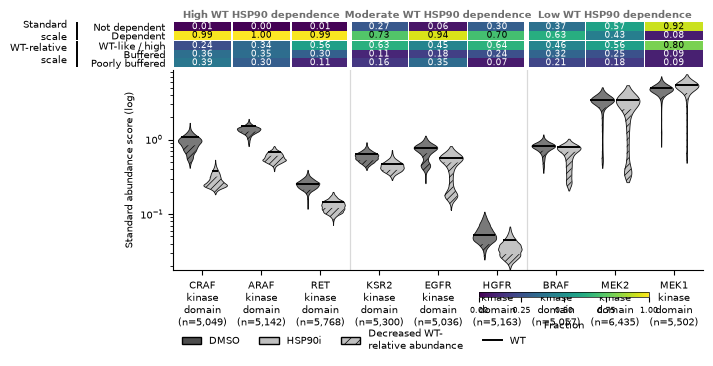

,not_dependent,dependent,wt_like,buffered,poorly_buffered
craf,0.010,0.990,0.235,0.363,0.395
araf,0.001,0.999,0.337,0.353,0.296
ret,0.008,0.992,0.561,0.305,0.109
ksr2,0.271,0.729,0.634,0.108,0.163
egfr,0.056,0.944,0.453,0.185,0.346
met,0.300,0.700,0.644,0.244,0.071
braf,0.375,0.625,0.457,0.321,0.208
mek2,0.575,0.425,0.559,0.247,0.175
mek1,0.919,0.081,0.799,0.089,0.087


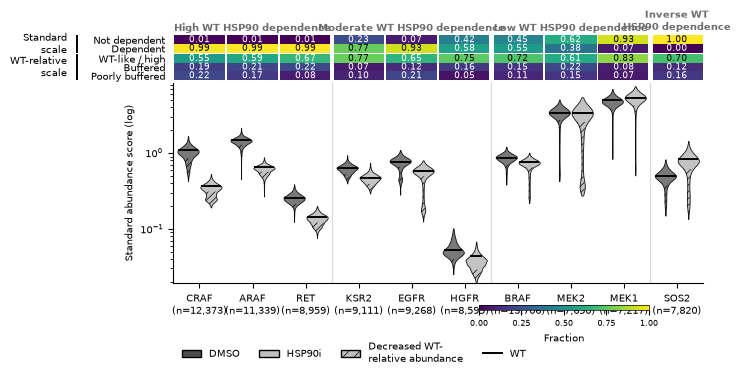

,not_dependent,dependent,wt_like,buffered,poorly_buffered
craf,0.010,0.990,0.549,0.185,0.216
araf,0.007,0.993,0.594,0.208,0.172
ret,0.007,0.993,0.665,0.220,0.081
ksr2,0.234,0.766,0.767,0.073,0.097
egfr,0.072,0.928,0.651,0.121,0.206
met,0.422,0.578,0.752,0.163,0.049
braf,0.452,0.548,0.719,0.152,0.105
mek2,0.615,0.385,0.609,0.222,0.149
mek1,0.932,0.068,0.829,0.076,0.070
sos2,0.996,0.004,0.703,0.122,0.163



kinase-domain paired, WT-relative scale: missense 46,253 (44,905 with a buffering class); missense+deletion 48,452 (47,060 with a class)


In [5]:
def plot_violin_panel(
    groups: Mapping[str, Sequence[float]] | None = None,
    *,
    series_groups: Mapping[str, Mapping[str, Sequence[float]]] | None = None,
    series_colors: Mapping[str, str] | None = None,
    series_dy: float = 0.20,
    series_width: float = 0.34,
    group_colors: Mapping[str, str] | None = None,
    median_bar: bool = False,
    bracket_vs: str | None = None,
    bracket_targets: Sequence[str] = (),
    bracket_gt_counts: Mapping[str, tuple[int, int]] | None = None,
    bracket_base: float | None = None,
    bracket_base_pad: float = 0.4,
    bracket_step: float = 0.9,
    bracket_tick: float = 0.2,
    bracket_dx: float = 0.14,
    bracket_fs: float = 6.5,
    bracket_stars_fn=stars_4tier_ns,
    ylim: tuple[float, float] | None = None,
    ylim_lo: float | None = None,
    ylim_lo_pct: float = 0.5,
    ylim_lo_pad: float = 0.5,
    ylim_top_pad: float = 0.5,
    xlim: tuple[float, float] | None = None,
    n_below: bool = False,
    ref_line: float | None = None,
    ref_color: str = "#999999",
    ref_ls: str = "--",
    ref_lw: float = 0.7,
    tight_layout: bool = False,
    ref_label: str = "",
    class_frac: pd.DataFrame | None = None,
    class_colors: Mapping[str, str] | None = None,
    class_order: Sequence[str] | None = None,
    point_overlay: pd.DataFrame | None = None,
    overlay_value_col: str | None = None,
    overlay_group_col: str | None = None,
    marker_values: Mapping[str, float] | None = None,
    marker_style: str = "dash",
    tiers: Sequence[tuple[str, Sequence[str]]] = (),
    tier_colors: Mapping[str, str] | None = None,
    tier_fs: float = 10.0,
    y_percent: bool = False,
    title_pad: float | None = None,
    violin_color: str = "#b9c2cf",
    violin_edge: str = "#4a5567",
    figsize: tuple[float, float] = (14.5, 9.4),
    height_ratios: Sequence[float] = (1.0, 4.5),
    widths: float = 0.78,
    show_violin_medians: bool = True,
    subplots_adjust: Mapping[str, float] | None = None,
    tick_labelsize: float | None = None,
    spine_lw: float | None = None,
    log_y: bool = False,
    hline: float | None = 1.0,
    ylabel: str = "Abundance score",
    show_n: bool = True,
    title: str = "",
    fs: Mapping[str, float] | None = None,
) -> tuple[Figure, np.ndarray]:
    F = {"tick": 11, "axis": 13, "legend": 11, "title": 14}
    F.update(fs or {})
    if (groups is None) == (series_groups is None):
        raise ValueError("pass exactly one of `groups` or `series_groups`")
    # Normalise both call styles to {series: {category: values}}.
    nested = ({None: groups} if series_groups is None
              else {k: v for k, v in series_groups.items()})
    cats = list(dict.fromkeys(c for g in nested.values() for c in g))
    pos = np.arange(len(cats))
    scolors = dict(series_colors or VARIANT_TYPE_COLORS)
    group_colors = dict(group_colors) if group_colors else None
    series = list(nested)
    offs = (np.linspace(series_dy, -series_dy, len(series)) if len(series) > 1
            else np.zeros(1))
    w = series_width if len(series) > 1 else widths
    def _vals(s, c):
        return np.asarray([v for v in nested[s].get(c, []) if np.isfinite(v)],
                          dtype=float)
    # Per-category n for the tick labels: total across series.
    data = [np.concatenate([_vals(s, c) for s in series]) if series else
            np.array([]) for c in cats]
    if class_frac is not None:
        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(2, 1, height_ratios=list(height_ratios),
                              hspace=0.06)
        ax_strip, ax = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])
    else:
        fig, ax = plt.subplots(figsize=figsize)
        ax_strip = None
    for si, s in enumerate(series):
        vv = [_vals(s, c) for c in cats]
        keep = [i for i, d in enumerate(vv) if d.size > 1]
        if not keep:
            continue
        parts = ax.violinplot([vv[i] for i in keep],
                              positions=pos[keep] + offs[si], widths=w,
                              showextrema=False,
                              showmedians=show_violin_medians)
        face = scolors.get(s, violin_color) if s is not None else violin_color
        for bi, b in zip(keep, parts["bodies"]):
            b.set_facecolor(group_colors.get(cats[bi], face) if group_colors
                            else face)
            b.set_edgecolor("#333333" if group_colors else
                            (violin_edge if s is None else "none"))
            b.set_alpha(0.85 if s is None else 0.8)
            b.set_linewidth(0.6 if group_colors else 0.5)
        if show_violin_medians:
            parts["cmedians"].set_color("#111111")
            parts["cmedians"].set_linewidth(1.1 if s is None else 0.9)
        if median_bar:
            # Wide flat median bar instead of the violin's thin default.
            if show_violin_medians:
                parts["cmedians"].set_alpha(0.0)
            for i in keep:
                ax.hlines(np.median(vv[i]), i - 0.34, i + 0.34,
                          color="#111111", linewidth=1.6, zorder=4)
    if marker_values:
        for i, c in enumerate(cats):
            v = marker_values.get(c)
            if v is None or not np.isfinite(v):
                continue
            if marker_style == "star":
                # Open star: reads as a distinct annotation against a filled
                # violin, where a dash would be mistaken for the median.
                ax.scatter(i, v, marker="*", s=120, facecolor="white",
                           edgecolor="black", linewidths=1.0, zorder=6)
            else:
                ax.plot([i - 0.30, i + 0.30], [v, v], color="#111111", lw=1.6,
                        zorder=6)
    if point_overlay is not None and overlay_value_col and overlay_group_col:
        rng = np.random.default_rng(0)
        for i, c in enumerate(cats):
            sub = point_overlay[point_overlay[overlay_group_col] == c]
            if not len(sub):
                continue
            ax.scatter(i + (rng.random(len(sub)) - 0.5) * 0.28,
                       sub[overlay_value_col].values, s=16, facecolor="white",
                       edgecolor="#333333", linewidth=0.6, zorder=5)
    if hline is not None:
        ax.axhline(hline, color="#666666", ls=":", lw=0.9)
    if log_y:
        ax.set_yscale("log")
    if ref_line is not None:
        ax.axhline(ref_line, color=ref_color, linewidth=ref_lw, linestyle=ref_ls,
                   zorder=1)
        if ref_label:
            ax.text(len(cats) - 0.55, ref_line + 0.25, ref_label, fontsize=7,
                    color="#777777", ha="right", va="bottom")
    ytop = None
    if bracket_vs is not None and bracket_targets:
        from scipy.stats import mannwhitneyu
        i_ref = cats.index(bracket_vs)
        vals = {c: data[cats.index(c)] for c in cats}
        base = (bracket_base if bracket_base is not None else
                max(np.percentile(v, 99.5) for v in vals.values() if v.size)
                + bracket_base_pad)
        step, tickh = bracket_step, bracket_tick
        for k, g in enumerate(bracket_targets):
            if g not in cats:
                continue
            i_g, y = cats.index(g), base + k * step
            _, pv = mannwhitneyu(vals[bracket_vs], vals[g],
                                 alternative="two-sided")
            note = bracket_stars_fn(pv)
            if bracket_gt_counts and g in bracket_gt_counts:
                n_gt, n_tot = bracket_gt_counts[g]
                note = f"{note}  > in {n_gt}/{n_tot}"
            ax.plot([i_g, i_g, i_ref, i_ref],
                    [y, y + tickh, y + tickh, y], color="#333333",
                    linewidth=0.9)
            ax.text(i_ref + bracket_dx, y + tickh, note, ha="left",
                    va="center", fontsize=bracket_fs)
        ytop = base + len(bracket_targets) * step + tickh
    if series_groups is not None:
        handles = [plt.Line2D([], [], color=scolors.get(s, violin_color), lw=5,
                              alpha=0.8, label=str(s)) for s in series]
        if marker_values:
            handles.append(plt.Line2D([], [], color="#111111", lw=1.6,
                                      label="wild type"))
        ax.legend(handles=handles, frameon=False, loc="upper right",
                  fontsize=F["legend"])
    # With brackets on, leave a full slot to the right so the annotations are
    # not clipped — the source figures use (-0.6, 4.6) for four groups.
    ax.set_xlim(*(xlim if xlim is not None else
                  ((-0.6, len(cats) + 0.6) if bracket_vs is not None
                   else (-0.6, len(cats) - 0.4))))
    ax.set_xticks(pos)
    tick = [protein_label(c) if str(c).lower() in PROTEIN_KEYS else str(c)
            for c in cats]
    if show_n:
        tick = [f"{t}\n(n={d.size:,})" for t, d in zip(tick, data)]
    if n_below:
        ax.set_xticklabels([protein_label(c) if str(c).lower() in PROTEIN_KEYS
                            else str(c) for c in cats], fontsize=F["tick"])
        for i, d in enumerate(data):
            ax.annotate(f"n={d.size:,}", xy=(i, 0),
                        xycoords=("data", "axes fraction"), xytext=(0, -15),
                        textcoords="offset points", ha="center", va="top",
                        fontsize=6.5, color="#333333", annotation_clip=False)
    else:
        ax.set_xticklabels(tick, rotation=45, ha="right", fontsize=F["tick"])
    if ylim is not None:
        ax.set_ylim(*ylim)
    elif ytop is not None:
        # Pooled percentile, not the minimum of the per-group percentiles.
        pooled = np.concatenate([d for d in data if d.size])
        lo = (ylim_lo if ylim_lo is not None
              else np.percentile(pooled, ylim_lo_pct) - ylim_lo_pad)
        ax.set_ylim(lo, ytop + ylim_top_pad)
    ax.set_ylabel(ylabel, fontsize=F["axis"])
    if tiers:
        # Dividers on the boundaries between tiers, and one bold caption per
        # tier in its own colour, anchored in axes fraction so it stays at the
        # visual top of the panel.
        edge = 0
        for _, members in list(tiers)[:-1]:
            edge += len(members)
            ax.axvline(edge - 0.5, color="0.85", lw=0.9, zorder=0)
        for caption, members in tiers:
            idxs = [cats.index(m) for m in members if m in cats]
            if not idxs:
                continue
            ax.text((idxs[0] + idxs[-1]) / 2, 1.02, caption, ha="center",
                    va="bottom", fontsize=tier_fs, fontweight="bold",
                    transform=ax.get_xaxis_transform(),
                    color=(tier_colors or {}).get(caption, "#111111"))
    if y_percent:
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _p: f"{v * 100:.0f}%"))
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    if ax_strip is not None:
        colors = dict(class_colors or BUFFERING_COLORS)
        order = list(class_order or [c for c in BUFFERING_ORDER
                                     if c in class_frac.columns])
        base = np.zeros(len(cats))
        for cls in order:
            v = class_frac.reindex(cats)[cls].fillna(0.0).values
            ax_strip.bar(pos, v, bottom=base, width=widths,
                         color=colors.get(cls, "#999999"), edgecolor="white",
                         linewidth=0.3, label=cls)
            base = base + v
        ax_strip.set_xlim(-0.6, len(cats) - 0.4)
        ax_strip.set_ylim(0, 1)
        ax_strip.set_xticks([])
        ax_strip.set_yticks([0, 0.5, 1])
        ax_strip.set_yticklabels(["0", "", "1"], fontsize=F["tick"] - 2)
        ax_strip.set_ylabel("fraction", fontsize=F["axis"] - 3)
        for s in ("top", "right"):
            ax_strip.spines[s].set_visible(False)
        ax_strip.legend(frameon=False, ncol=len(order),
                        bbox_to_anchor=(0.0, 1.02), loc="lower left",
                        fontsize=F["legend"])
        if title:
            ax_strip.set_title(title, loc="left", pad=26, fontsize=F["title"], fontname="Arial")
    elif title:
        ax.set_title(title, loc="left", fontsize=F["title"], fontname="Arial",
                     **({"pad": title_pad} if title_pad else {}))
    if tick_labelsize is not None:
        ax.tick_params(axis="both", labelsize=tick_labelsize)
    if spine_lw is not None:
        for s in ("left", "bottom"):
            ax.spines[s].set_linewidth(spine_lw)
    if subplots_adjust:
        fig.subplots_adjust(**subplots_adjust)
    if tight_layout:
        fig.tight_layout()
    return fig, np.array([a for a in (ax_strip, ax) if a is not None],
                         dtype=object)

def plot_paired_score_violins(
    arrays: Mapping[tuple[str, str], np.ndarray],
    wt: Mapping[tuple[str, str], float],
    thresholds: Mapping[tuple[str, str], float],
    heatmap: Mapping[str, Mapping[str, float]],
    *,
    groups: Sequence[tuple[str, Sequence[str]]],
    group_fill: Mapping[str, str],
    heatmap_rows: Sequence[str],
    heatmap_labels: Mapping[str, str],
    n_standard_rows: int = 2,
    figsize: tuple[float, float] = (16.0, 8.9),
    height_ratios: tuple[float, float] = (1.0, 4.2),
    margins: tuple[float, float, float, float] = (0.20, 0.98, 0.10, 0.90),
    stride: float = 1.25,
    half: float = 0.27,
    width: float = 0.50,
    xtick_fmt: str = "{label}\n(n={n:,})",
    trim_pct: tuple[float, float] | None = None,
    ylim_pct: tuple[float, float] = (0.5, 99.5),
    ylabel: str = "Standard abundance score (log)",
    low_legend_label: str = "Decreased WT-\nrelative abundance",
    bracket_labels: tuple[str, str] = ("Standard\nscale", "WT-relative\nscale"),
    legend_y: float = -0.18,
    fs: Mapping[str, float] | None = None,
) -> tuple[Figure, Axes, Axes]:
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch, Polygon, Rectangle
    import matplotlib.ticker as mticker
    F = {"xtick": 15.0, "ytick": 15.0, "ylabel": 15.0, "cell": 12.0,
         "row": 13.0, "bracket": 13.0, "group": 15.0, "legend": 15.0}
    F.update(fs or {})
    proteins = [p for _, ps in groups for p in ps]
    group_of = {p: g for g, ps in groups for p in ps}
    L, R, B, T = margins
    plt.rcParams["hatch.linewidth"] = 0.5
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=list(height_ratios), hspace=0.02,
                          left=L, right=R, top=T, bottom=B)
    ax_top = fig.add_subplot(gs[0])
    ax = fig.add_subplot(gs[1], sharex=ax_top)
    def _trim(v, pct):
        if pct is None or v.size == 0:
            return v
        lo, hi = np.nanpercentile(v, pct[0]), np.nanpercentile(v, pct[1])
        out = v[(v >= lo) & (v <= hi)]
        return out if out.size > 1 else v
    pos_ctrl, pos_hsp, ser_ctrl, ser_hsp, fill_ctrl, fill_hsp = [], [], [], [], [], []
    for i, p in enumerate(proteins, start=1):
        center = i * stride
        pos_ctrl.append(center - half)
        pos_hsp.append(center + half)
        ser_ctrl.append(_trim(np.log10(arrays[(p, "ctrl")]), trim_pct))
        ser_hsp.append(_trim(np.log10(arrays[(p, "hsp90i")]), trim_pct))
        tier = mcolors.to_rgba(group_fill[group_of[p]])
        fill_ctrl.append(tier)
        # Lighten toward white for HSP90i: dark = control, light = inhibited.
        fill_hsp.append(tuple(c + (1.0 - c) * 0.55 for c in tier[:3]) + (tier[3],))
    def _draw(positions, series, fills):
        # showmedians=False: the WT line is the only horizontal annotation, so
        # a median tick would be read as the WT marker.
        parts = ax.violinplot(series, positions=positions, showmeans=False,
                              showmedians=False, showextrema=False, widths=width)
        for body, fc in zip(parts["bodies"], fills):
            body.set_facecolor(fc)
            body.set_edgecolor("black")
            body.set_linewidth(0.6)
            body.set_alpha(0.92)
        return parts
    parts_ctrl = _draw(pos_ctrl, ser_ctrl, fill_ctrl)
    parts_hsp = _draw(pos_hsp, ser_hsp, fill_hsp)
    def _edges(body, center_x):
        verts = body.get_paths()[0].vertices
        right = verts[verts[:, 0] > center_x]
        left = verts[verts[:, 0] < center_x]
        if len(right) == 0 or len(left) == 0:
            return None, None
        return right[np.argsort(right[:, 1])], left[np.argsort(left[:, 1])]
    def _halfwidth_at(body, y_target, center_x):
        right, left = _edges(body, center_x)
        if right is None:
            return 0.0
        y_lo, y_hi = max(right[0, 1], left[0, 1]), min(right[-1, 1], left[-1, 1])
        if y_target < y_lo or y_target > y_hi:
            return 0.0
        return float(np.interp(y_target, right[:, 1], right[:, 0])
                     - np.interp(y_target, left[:, 1], left[:, 0])) / 2.0
    def _sub_polygon_below(body, y_threshold, center_x):
        right, left = _edges(body, center_x)
        if right is None:
            return None
        y_lo, y_hi = max(right[0, 1], left[0, 1]), min(right[-1, 1], left[-1, 1])
        if y_threshold <= y_lo:
            return None
        if y_threshold >= y_hi:
            return np.concatenate([right, left[::-1]])
        r_cross = float(np.interp(y_threshold, right[:, 1], right[:, 0]))
        l_cross = float(np.interp(y_threshold, left[:, 1], left[:, 0]))
        return np.array(
            list(right[right[:, 1] < y_threshold].tolist())
            + [[r_cross, y_threshold], [l_cross, y_threshold]]
            + list(left[left[:, 1] < y_threshold][::-1].tolist()))
    # Hatch the "low" region of every violin. facecolor="none" + lw=0 keeps the
    # violin's own colour showing through, so only the texture is added.
    for which, parts, positions in (("ctrl", parts_ctrl, pos_ctrl),
                                    ("hsp90i", parts_hsp, pos_hsp)):
        for i, p in enumerate(proteins):
            thr = thresholds.get((p, which), np.nan)
            wt_v = wt.get((p, which), np.nan)
            if not (np.isfinite(thr) and thr > 0):
                continue
            # The cutoff should always sit below WT (2.5th pct of syn-WT <
            # median syn-WT ~ WT); skip if a noisy WT row inverts that.
            if np.isfinite(wt_v) and thr >= wt_v:
                continue
            sub = _sub_polygon_below(parts["bodies"][i], float(np.log10(thr)),
                                     positions[i])
            if sub is None or len(sub) < 3:
                continue
            ax.add_patch(Polygon(sub, closed=True, facecolor="none",
                                 edgecolor="black", linewidth=0.0,
                                 hatch="/////", zorder=2.5))
    for i, p in enumerate(proteins, start=1):
        center = i * stride
        for tx, pos, body in (("ctrl", center - half, parts_ctrl["bodies"][i - 1]),
                              ("hsp90i", center + half, parts_hsp["bodies"][i - 1])):
            v = wt.get((p, tx), np.nan)
            if not (np.isfinite(v) and v > 0):
                continue
            y = float(np.log10(v))
            hw = _halfwidth_at(body, y, pos)
            if hw > 0:
                ax.hlines(y, pos - hw, pos + hw, color="black", linewidth=1.4,
                          zorder=6)
    # Tier dividers, derived from group sizes so membership changes track.
    edge = 0
    for _, ps in groups[:-1]:
        edge += len(ps)
        ax.axvline((edge + 0.5) * stride, color="0.85", lw=0.9, zorder=0)
    ax.set_xticks(np.arange(1, len(proteins) + 1) * stride)
    ax.set_xticklabels([xtick_fmt.format(label=protein_label(p),
                                        n=int(heatmap[p].get("_n", 0)))
                        for p in proteins], fontsize=F["xtick"])
    ax.set_xlim(0.4 * stride, (len(proteins) + 0.6) * stride)
    pooled = np.concatenate(ser_ctrl + ser_hsp)
    y_lo = float(np.nanpercentile(pooled, ylim_pct[0]))
    y_hi = float(np.nanpercentile(pooled, ylim_pct[1]))
    pad = (y_hi - y_lo) * 0.06
    ax.set_ylim(y_lo - pad, y_hi + pad)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1.0))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(
        lambda v, _p: f"$10^{{{int(round(v))}}}$"
        if abs(v - round(v)) < 1e-6 else ""))
    ax.yaxis.set_minor_locator(mticker.FixedLocator(
        [np.log10(b) + d for d in range(int(np.floor(y_lo)) - 1,
                                        int(np.ceil(y_hi)) + 1)
         for b in range(2, 10)]))
    ax.tick_params(axis="y", labelsize=F["ytick"])
    ax.set_ylabel(ylabel, fontsize=F["ylabel"])
    # --- composition heatmap ------------------------------------------------
    rows = list(heatmap_rows)
    data = np.array([[heatmap[p].get(k, np.nan) for p in proteins] for k in rows],
                    dtype=float)
    n_rows, n_cols = len(rows), len(proteins)
    wtrel_n = n_rows - n_standard_rows
    V_GAP = 0.18
    total_h = n_rows + V_GAP
    standard_y = (0.0, float(n_standard_rows))
    wtrel_y = (n_standard_rows + V_GAP, n_standard_rows + V_GAP + wtrel_n)
    cmap = plt.get_cmap("viridis")
    ax_w_in = (R - L) * figsize[0]
    ax_h_in = (T - B) * figsize[1] * (height_ratios[0] / sum(height_ratios))
    h_gap_small = V_GAP * (((n_cols * stride) / ax_w_in) / (total_h / ax_h_in))
    h_gap_large = 3.0 * h_gap_small
    group_end = set(np.cumsum([len(ps) for _, ps in groups])[:-1] - 1)
    def _cell_lr(c):
        center = (c + 1) * stride
        right = (h_gap_small / 2 if c == n_cols - 1 else
                 h_gap_large / 2 if c in group_end else h_gap_small / 2)
        left = (h_gap_small / 2 if c == 0 else
                h_gap_large / 2 if (c - 1) in group_end else h_gap_small / 2)
        return center - 0.5 * stride + left, center + 0.5 * stride - right
    row_centers = ([r + 0.5 for r in range(n_standard_rows)]
                   + [n_standard_rows + V_GAP + (r - n_standard_rows) + 0.5
                      for r in range(n_standard_rows, n_rows)])
    for r in range(n_rows):
        y_top = (standard_y[0] + r if r < n_standard_rows
                 else wtrel_y[0] + (r - n_standard_rows))
        for c in range(n_cols):
            v = data[r, c]
            if not np.isfinite(v):
                continue
            lx, rx = _cell_lr(c)
            ax_top.add_patch(Rectangle((lx, y_top), rx - lx, 1.0,
                                       facecolor=cmap(v), edgecolor="none"))
            # Perceptual luminance picks the text colour so labels stay legible
            # across the whole viridis range.
            rgba = cmap(v)
            lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            ax_top.text((c + 1) * stride, row_centers[r], f"{v:.2f}",
                        ha="center", va="center", fontsize=F["cell"],
                        color="white" if lum < 0.55 else "black")
    ax_top.set_xlim(0.5 * stride, (n_cols + 0.5) * stride)
    ax_top.set_ylim(total_h, 0.0)
    ax_top.set_yticks(row_centers)
    ax_top.set_yticklabels([heatmap_labels[k] for k in rows], fontsize=F["row"])
    ax_top.tick_params(axis="y", which="both", left=False, pad=2)
    ax_top.tick_params(axis="x", which="both", bottom=False, top=False,
                       labelbottom=False)
    for sp in ("top", "right", "left", "bottom"):
        ax_top.spines[sp].set_visible(False)
    # Scale brackets, outside the row-label gutter. x in axes fraction, y in
    # data, so they stay attached to the rows once the group gap shifts them.
    blended = ax_top.get_yaxis_transform()
    for label, (y0, y1) in zip(bracket_labels, (standard_y, wtrel_y)):
        ax_top.plot([-0.18, -0.18], [y0, y1], transform=blended, color="black",
                    linewidth=1.4, clip_on=False, solid_capstyle="butt")
        ax_top.text(-0.20, (y0 + y1) / 2, label, transform=blended,
                    ha="right", va="center", fontsize=F["bracket"])
    for label, ps in groups:
        idxs = [proteins.index(p) + 1 for p in ps]
        ax_top.text((idxs[0] + idxs[-1]) / 2 * stride, 1.05, label,
                    ha="center", va="bottom", fontsize=F["group"],
                    fontweight="bold", transform=ax_top.get_xaxis_transform(),
                    color=group_fill[label])
    # Neutral grey/black swatches rather than one tier's colour, so the
    # dark = control / light = HSP90i convention reads independent of palette.
    # Legend and colorbar at the bottom
    handles = [
        Patch(facecolor="#4d4d4d", edgecolor="black", label="DMSO"),
        Patch(facecolor="#bfbfbf", edgecolor="black", label="HSP90i"),
        Patch(facecolor="#bfbfbf", edgecolor="black", hatch="///",
              label=low_legend_label),
        Line2D([0], [0], color="black", linewidth=1.4, label="WT"),
    ]
    ax.legend(handles=handles, loc="lower left", ncol=4, frameon=False,
              bbox_to_anchor=(0.0, legend_y), fontsize=F["legend"])

    # Horizontal colorbar for the heatmap, bottom-right
    cbar_ax = fig.add_axes([0.65, B * 0.15, 0.25, 0.015])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal",
                        ticks=[0, 0.25, 0.5, 0.75, 1.0])
    cbar.set_label("Fraction", fontsize=F["legend"])
    cbar.ax.tick_params(labelsize=F["legend"] - 1)
    cbar.outline.set_linewidth(0.5)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return fig, ax, ax_top

# === VISUAL CONFIG ===
FONT_SIZES = {"axis": 7.0, "tick": 7.0, "legend": 7.0, "title": 9.0, "annot": 6.5}
LINE_WIDTHS = {"axes": 0.6, "plot": 1.2}
SCORE_ABS = "intercept_0_standard-adjusted score"
NOTLOW = ("wt-like", "high")
DEP_GROUPS_KD = [                          # 4D: kinase domain, so no SOS2
    ("High WT HSP90 dependence",     ["craf", "araf", "ret"]),
    ("Moderate WT HSP90 dependence", ["ksr2", "egfr", "met"]),
    ("Low WT HSP90 dependence",      ["braf", "mek2", "mek1"]),
]
assert [p for _, ps in DEP_GROUPS_KD for p in ps] == HSP90_ORDER
DEP_GROUPS_ALL = DEP_GROUPS_KD + [("Inverse WT\nHSP90 dependence", ["sos2"])]
# Dark -> warm ramp, deliberately clear of the buffering red/orange/blue so a
# tier colour is never read as a buffering class.
GROUP_FILL = DEPENDENCE_COLORS

HEATMAP_KEYS = ("not_dependent", "dependent",
                "wt_like", "buffered", "poorly_buffered")
HEATMAP_LABELS = {"not_dependent": "Not dependent", "dependent": "Dependent",
                  "wt_like": "WT-like / high", "buffered": "Buffered",
                  "poorly_buffered": "Poorly buffered"}
abs_mf = Replicate_scores[(Replicate_scores.assay == "abundance")
                          & Replicate_scores.assay_treatment.isin(
                              ["DMSO", "No_treatment", "HSP90i"])].copy()
abs_mf["tx"] = np.where(abs_mf.assay_treatment == "HSP90i", "hsp90i", "ctrl")

def violin_inputs(proteins, *, kinase_only: bool):
    miss = abs_mf[abs_mf["Mutation Type"].isin(["missense", "deletion"])]
    if kinase_only:
        miss = miss[miss.domain == "kinase"]
    syn = abs_mf[abs_mf["Mutation Type"] == "synonymous wild type"]
    wt_rows = abs_mf[abs_mf["Mutation Type"] == "wild type"]
    arrays, wt, thresholds, heat = {}, {}, {}, {}
    for p in proteins:
        mp = miss[miss.protein == p]
        # For 4D the library is the one the kinase-domain missense sits in.
        libs = ([mp.library.mode().iloc[0]] if kinase_only and len(mp)
                else sorted(abs_mf.loc[abs_mf.protein == p, "library"].unique()))
        for tx in ("ctrl", "hsp90i"):
            s = mp[(mp.tx == tx) & mp.library.isin(libs)][SCORE_ABS].dropna()
            # Clip at a display floor: log10(0) is undefined and a handful of
            # pathological negatives would otherwise set the axis range.
            arrays[(p, tx)] = np.clip(s.to_numpy(dtype=float), 0.01, None)
            w = wt_rows[(wt_rows.protein == p) & (wt_rows.tx == tx)
                        & wt_rows.library.isin(libs)][SCORE_ABS]
            wt[(p, tx)] = float(w.mean()) if len(w) else np.nan
            sy = syn[(syn.protein == p) & (syn.tx == tx)
                     & syn.library.isin(libs)][SCORE_ABS].dropna()
            thresholds[(p, tx)] = (float(np.percentile(sy.to_numpy(), 2.5))
                                   if len(sy) else np.nan)
        # Buffering fractions: pair within library, then pool.
        parts = []
        for lib in libs:
            sl = mp[mp.library == lib]
            c = (sl[sl.tx == "ctrl"][["variant", SCORE_ABS, "classification_2.5pct"]]
                 .rename(columns={SCORE_ABS: "s_c", "classification_2.5pct": "cl_c"}))
            h = (sl[sl.tx == "hsp90i"][["variant", SCORE_ABS, "classification_2.5pct"]]
                 .rename(columns={SCORE_ABS: "s_h", "classification_2.5pct": "cl_h"}))
            m = c.merge(h, on="variant")
            if len(m):
                parts.append(m)
        if not parts:
            heat[p] = {k: np.nan for k in HEATMAP_KEYS} | {"_n": 0}
            continue
        m = pd.concat(parts, ignore_index=True)
        n = len(m)
        wt_dmso = wt[(p, "ctrl")]
        syn_2p5 = thresholds[(p, "ctrl")]
        gap = (max(0.0, wt_dmso - syn_2p5)
               if np.isfinite(wt_dmso) and np.isfinite(syn_2p5) else 0.0)
        dep = float(((m.s_c - m.s_h) >= gap).sum() / n)
        c_nl, h_nl = m.cl_c.isin(NOTLOW), m.cl_h.isin(NOTLOW)
        c_lo, h_lo = m.cl_c == "low", m.cl_h == "low"
        heat[p] = {
            "not_dependent": 1.0 - dep, "dependent": dep,
            "wt_like": float((c_nl & h_nl).sum() / n),
            "buffered": float((c_nl & h_lo).sum() / n),
            "poorly_buffered": float((c_lo & h_lo).sum() / n),
            "_n": n,
        }
    return arrays, wt, thresholds, heat
TRIM = (0.25, 99.75)

# 4D — kinase-domain missense and deletion
a, w, th, hm = violin_inputs([p for _, ps in DEP_GROUPS_KD for p in ps],
                             kinase_only=True)

fig, _, _ = plot_paired_score_violins(
    a, w, th, hm, groups=DEP_GROUPS_KD, group_fill=GROUP_FILL,
    heatmap_rows=HEATMAP_KEYS, heatmap_labels=HEATMAP_LABELS,
    figsize=(6.8, 3.1), height_ratios=(1.0, 4.5), trim_pct=TRIM,
    xtick_fmt="{label}\nkinase\ndomain\n(n={n:,})", legend_y=-0.45,
    fs={"axis": 7.0, "xtick": 7.0, "ytick": 7.0, "ylabel": 7.0,
        "cell": 6.5, "row": 7.0, "bracket": 7.0, "group": 7,
        "legend": 7.0})

save_figure(fig, FIG / "5d_kinase_domain_violins")
plt.show()
display(pd.DataFrame(hm).T[list(HEATMAP_KEYS)].round(3))

# S4A — all missense and deletion
a2, w2, th2, hm2 = violin_inputs([p for _, ps in DEP_GROUPS_ALL for p in ps],
                                 kinase_only=False)

fig, _, _ = plot_paired_score_violins(
    a2, w2, th2, hm2, groups=DEP_GROUPS_ALL, group_fill=GROUP_FILL,
    heatmap_rows=HEATMAP_KEYS, heatmap_labels=HEATMAP_LABELS,
    figsize=(6.8, 3.1), height_ratios=(1.0, 4.5), trim_pct=TRIM,
    xtick_fmt="{label}\n(n={n:,})", legend_y=-0.45,
    low_legend_label="Decreased WT-\nrelative abundance",
    ylabel="Standard abundance score (log)",
    fs={"axis": 7.0, "xtick": 7.0, "ytick": 7.0, "ylabel": 7.0,
        "cell": 6.5, "row": 7.0, "bracket": 7.0, "group": 7,
        "legend": 7.0})

save_figure(fig, FIG / "ExtDataHSP908a_all_missense_violins")
plt.show()
display(pd.DataFrame(hm2).T[list(HEATMAP_KEYS)].round(3))

# Kinase-domain cohorts for downstream panels
kd = paired[paired.domain == "kinase"]
kd_md = paired_md[paired_md.domain == "kinase"]

print(f"\nkinase-domain paired, WT-relative scale: missense {len(kd):,} "
      f"({int(kd.buffering_class.notna().sum()):,} with a buffering class); "
      f"missense+deletion {len(kd_md):,} "
      f"({int(kd_md.buffering_class.notna().sum()):,} with a class)")

## 4E — buffering on the kinase fold

In [49]:
def plot_structure(
    out_stem: str | Path,
    *,
    structure: str,
    query_chains: Sequence[str] = ("A",),
    sphere_counts: Mapping[int, float] | None = None,
    residue_values: Mapping[int, float] | None = None,
    sphere_color: tuple[float, float, float] | str = (0.75, 0.16, 0.16),
    cmap: str = "Reds",
    vmin: float = 0.0,
    vmax: float = 1.0,
    nodata_color: str = "gray35",
    radius_range: tuple[float, float] = (0.6, 3.5),
    count_range: tuple[float, float] = (1.0, 20.0),
    partners: Sequence[tuple[str, str, str] | Mapping] = (),
    ligands: Sequence[str] = (),
    graft: Mapping | None = None,
    ligand_color: str = "yellow",
    ion_vdw: float = 0.9,
    cartoon_color: str = STRUCT_CARTOON_COLOR,
    view: Sequence[float] | None = None,
    align_to: str | None = None,
    align_chain: str = "A",
    align_resi: tuple[int, int] | None = None,
    align_rotations: Sequence[tuple[str, float]] = (),
    px_per_angstrom: float = 14.0,
    pad_angstrom: float = 6.0,
    cartoon_pad_angstrom: float = 4.0,
    max_px: int = 3000,
    bg_color: str = "white",
    save_pse: bool = True,
    run: bool = True,
    extra_commands: Sequence[str] = (),
) -> Path:
    out_stem = Path(out_stem)
    out_stem.parent.mkdir(parents=True, exist_ok=True)
    pml = out_stem.with_suffix(".pml")
    obj = out_stem.name.upper().replace("-", "_").replace(".", "_")
    if str(structure).startswith("fetch:"):
        PYMOL_FETCH_CACHE.mkdir(parents=True, exist_ok=True)
        load = f"fetch {str(structure).split(':', 1)[1]}, {obj}, async=0"
    else:
        load = f"load {Path(structure).resolve()}, {obj}"
    q_sel = " or ".join(f"chain {c}" for c in query_chains)
    L = [f"# {out_stem.name}",
         f"set fetch_path, {PYMOL_FETCH_CACHE.resolve()}"]
    if align_to is not None:
        if str(align_to).startswith("fetch:"):
            L.append(f"fetch {str(align_to).split(':', 1)[1]}, _anchor_raw, async=0")
        else:
            L.append(f"load {Path(align_to).resolve()}, _anchor_raw")
        rng = f" and resi {align_resi[0]}-{align_resi[1]}" if align_resi else ""
        L += ["remove _anchor_raw and (solvent or hetatm)",
              f"create _pose_anchor, _anchor_raw and chain {align_chain} "
              f"and polymer{rng}",
              "delete _anchor_raw", "orient _pose_anchor"]
        for axis, angle in align_rotations:
            L.append(f"rotate {axis}, {angle}, _pose_anchor")
    L += [load, "remove solvent", "remove hydro", "hide everything",
          f"select query_sel, {obj} and ({q_sel})",
          "show cartoon, query_sel",
          f"color {cartoon_color}, query_sel"]
    if align_to is not None:
        # cealign gets within a few Angstrom; `super` refines it. cealign alone
        # leaves ~3 A RMSD, which visibly tilts the kinase.
        L += ["cealign _pose_anchor, query_sel",
              "super query_sel, _pose_anchor, cycles=5",
              "hide everything, _pose_anchor", "delete _pose_anchor"]
    if graft:
        g_src = str(graft["structure"])
        if g_src.startswith("fetch:"):
            L.append(f"fetch {g_src.split(':', 1)[1]}, _graft_raw, async=0")
        else:
            L.append(f"load {Path(g_src).resolve()}, _graft_raw")
        g_chain = graft.get("align_chain", "A")
        lo, hi = graft["align_resi"]
        L += ["remove _graft_raw and solvent",
              f"create _graft_ref, _graft_raw and chain {g_chain} and polymer "
              f"and resi {lo}-{hi}",
              f"align _graft_ref, {obj} and ({q_sel}) and resi {lo}-{hi}, "
              "cycles=5, object=_graft_aln",
              "python",
              "m = cmd.get_object_matrix('_graft_ref')",
              "cmd.transform_object('_graft_raw', m)",
              "python end",
              f"create graft_sel, _graft_raw and chain {graft['keep_chain']}",
              "delete _graft_ref", "delete _graft_aln", "delete _graft_raw",
              "hide everything, graft_sel",
              "show sticks, graft_sel",
              f"color {graft.get('color', 'yellow')}, graft_sel",
              "python",
              "from pymol import util",
              "util.cnc('graft_sel')",
              f"print('grafted {graft.get('label', 'ligand')}: %d atoms' % "
              "cmd.count_atoms('graft_sel'))",
              "python end"]
    partner_specs = []
    for i, rec in enumerate(partners):
        d = (dict(zip(("chain", "label", "color"), rec))
             if isinstance(rec, (tuple, list)) else dict(rec))
        safe = "".join(c if c.isalnum() or c in "._" else "_"
                       for c in str(d["label"]))
        d["sel"] = f"partner_{i}_{safe}"
        partner_specs.append(d)
        L += [f"select {d['sel']}, {obj} and chain {d['chain']}",
              f"color {d['color']}, {d['sel']}", "python",
              f"n_ca = cmd.count_atoms('{d['sel']} and name CA')",
              f"cmd.show('sticks' if n_ca <= 15 else 'cartoon', '{d['sel']}')",
              "python end"]
    if residue_values:
        cm, span = plt.get_cmap(cmap), (vmax - vmin) or 1.0
        L += [f"color {nodata_color}, query_sel",
              "set cartoon_smooth_loops, 0", "set cartoon_discrete_colors, 1"]
        by_colour: dict[tuple, list[int]] = {}
        for pos, val in residue_values.items():
            if val is None or not np.isfinite(val):
                continue
            rgb = tuple(round(c, 3) for c in
                        cm(min(max((val - vmin) / span, 0.0), 1.0))[:3])
            by_colour.setdefault(rgb, []).append(int(pos))
        for k, (rgb, positions) in enumerate(sorted(by_colour.items())):
            L += [f"set_color ramp_{k}, [{rgb[0]}, {rgb[1]}, {rgb[2]}]",
                  f"color ramp_{k}, {obj} and ({q_sel}) and resi "
                  + "+".join(str(x) for x in sorted(positions))]
    def _sphere_cmds(sel_expr: str, counts, colour, tag: str) -> list[str]:
        c0, c1 = count_range
        r0, r1 = radius_range
        out: list[str] = []
        if isinstance(colour, str):
            name = colour
        else:
            name = f"sphere_col_{tag}"
            out.append(f"set_color {name}, [{colour[0]:.3f}, "
                       f"{colour[1]:.3f}, {colour[2]:.3f}]")
        by_radius: dict[float, list[int]] = {}
        for pos, n in counts.items():
            if n is None or not np.isfinite(n) or n < c0:
                continue
            frac = (min(float(n), c1) - c0) / max(c1 - c0, 1e-9)
            by_radius.setdefault(round(r0 + frac * (r1 - r0), 3),
                                 []).append(int(pos))
        for radius, positions in sorted(by_radius.items()):
            out.append(f"alter (({sel_expr}) and resi "
                       + "+".join(str(x) for x in sorted(positions))
                       + f" and name CA), vdw={radius:.3f}")
        allp = sorted(x for ps in by_radius.values() for x in ps)
        if allp:
            out += ["rebuild",
                    f"select dn_spheres_{tag}, ({sel_expr}) and resi "
                    + "+".join(str(x) for x in allp) + " and name CA",
                    f"show spheres, dn_spheres_{tag}",
                    f"color {name}, dn_spheres_{tag}",
                    "python",
                    f"print('spheres {tag}: %d of {len(allp)} positions present "
                    f"in this structure' % cmd.count_atoms('dn_spheres_{tag}'))",
                    "python end"]
        return out
    partner_sphere_specs = [d for d in partner_specs if d.get("sphere_counts")]
    if sphere_counts or partner_sphere_specs:
        # Shrink every atom first, once, so only the residues given a radius
        # below render as spheres.
        L += ["alter all, vdw=0.01", "rebuild"]
        if sphere_counts:
            L += _sphere_cmds(f"{obj} and ({q_sel})", sphere_counts,
                              sphere_color, "query")
        for i, d in enumerate(partner_sphere_specs):
            L += _sphere_cmds(f"{obj} and chain {d['chain']}",
                              d["sphere_counts"],
                              d.get("sphere_color", sphere_color), f"p{i}")
    if ligands:
        # After the sphere pass, because that sets vdw=0.01 on every atom to
        # keep unmarked residues from rendering as spheres — the ions need their
        # radius restored afterwards or they vanish.
        resn = "+".join(str(r).upper() for r in ligands)
        L += [f"select ligand_sel, {obj} and ({q_sel}) and resn {resn}",
              "python",
              "from pymol import util",
              "cmd.show('sticks', 'ligand_sel and not (elem MG+ZN+CA+MN+NA+K+CL+FE)')",
              "cmd.show('spheres', 'ligand_sel and elem MG+ZN+CA+MN+NA+K+CL+FE')",
              f"cmd.alter('ligand_sel and elem MG+ZN+CA+MN+NA+K+CL+FE', 'vdw={ion_vdw}')",
              "cmd.rebuild()",
              f"cmd.color('{ligand_color}', 'ligand_sel')",
              # Non-carbon atoms back to element colours, so the phosphates and
              # ribose of a nucleotide stay legible instead of a yellow blob.
              "util.cnc('ligand_sel and not (elem MG+ZN+CA+MN+NA+K+CL+FE)')",
              "print('ligand atoms shown: %d' % cmd.count_atoms('ligand_sel'))",
              "python end",
              "set stick_radius, 0.20"]
    L += [f"bg_color {bg_color}", "set ray_shadows, 0", "set antialias, 2",
          "set ray_opaque_background, 1", "set sphere_quality, 4",
          "set cartoon_fancy_helices, 1", "set depth_cue, 0",
          "set specular, 0.25", "set orthoscopic, on", *extra_commands]
    png = out_stem.with_suffix(".png").resolve()
    # Everything that carries a sphere must be inside the frame, not just the
    # query chain — otherwise a partner's DNs would be cropped.
    framed = " or ".join([f"{obj} and ({q_sel})"]
                         + [f"{obj} and chain {d['chain']}"
                            for d in partner_specs]
                         + (["ligand_sel"] if ligands else [])
                         + (["graft_sel"] if graft else []))
    L.append(f"select framed_sel, {framed}")
    _fit = ["python",
            "import math",
            "v = list(cmd.get_view())",
            "fov = abs(v[17]) or 20.0",
            "R, org = v[0:9], v[12:15]",
            "P = cmd.get_coords('framed_sel')",
            "def _proj(k, off):",
            "    return [R[3 * k] * (q[0] - org[0]) + R[3 * k + 1] * (q[1] - org[1])"
            " + R[3 * k + 2] * (q[2] - org[2]) + off for q in P]",
            "xs, ys, zs = _proj(0, v[9]), _proj(1, v[10]), _proj(2, 0.0)",
            f"pad = {pad_angstrom} + {radius_range[1]} + {cartoon_pad_angstrom}",
            "half = lambda s: max(abs(min(s)), abs(max(s)))",
            "side = 2 * max(half(xs), half(ys)) + 2 * pad",
            "d = side / (2.0 * math.tan(math.radians(fov) / 2.0))",
            "v[11] = -d",
            "v[15] = max(1.0, d - half(zs) - pad)",
            "v[16] = d + half(zs) + pad",
            "cmd.set_view(v)",
            f"n = min(int(round(side * {px_per_angstrom})), {max_px})",
            "print('fit %.1f A square (pad %.1f) -> %d px (%.2f px/A)'"
            " % (side, pad, n, n / side))",
            f"cmd.png(r'{png}', width=n, height=n, dpi=300, ray=1)",
            "python end"]
    if view is not None:
        # A pinned view supplies the ORIENTATION and CENTRING; its zoom is
        # refit above so nothing is cropped.
        L += ["set_view (" + ", ".join(f"{v:.6f}" for v in view) + ")"] + _fit
    else:
        # No curated view: PyMOL's own principal-axes orientation, which is
        # reproducible but arbitrary. Same sizing rule from there.
        L += ["orient framed_sel"] + _fit
    if save_pse:
        L.append(f"save {out_stem.with_suffix('.pse').resolve()}")
    pml.write_text("\n".join(L) + "\n")
    if run:
        if not PYMOL_BIN.exists():
            raise FileNotFoundError(
                f"PyMOL not found at {PYMOL_BIN}. Set the PYMOL env var.")
        res = subprocess.run([str(PYMOL_BIN), "-cq", str(pml)],
                             capture_output=True, text=True, timeout=900)
        if res.returncode != 0:
            raise RuntimeError(f"PyMOL failed on {pml.name}:\n"
                               f"{res.stdout[-800:]}\n{res.stderr[-800:]}")
    return pml

# === VISUAL CONFIG ===
FONT_SIZES = {"axis": 8.0, "tick": 7.0, "legend": 7.0, "title": 9.0, "annot": 6.5}
LINE_WIDTHS = {"axes": 0.6, "plot": 1.2}
# =====================
per_pos = (kd.dropna(subset=["buffering_class"])
           .groupby(["protein", "Position", "buffering_class"]).size()
           .unstack(fill_value=0))
per_pos["n"] = per_pos.sum(axis=1)
for cls in BUFFERING_ORDER:
    if cls not in per_pos:
        per_pos[cls] = 0
    per_pos[f"frac_{cls.replace(' ', '_').replace('-', '_').lower()}"] = (
        per_pos[cls] / per_pos["n"])
out = FIG / "fig4e_per_position_buffering.tsv"
per_pos.reset_index().to_csv(out, sep="\t", index=False)
print(f"wrote {out.relative_to(PROJECT_ROOT)}  ({len(per_pos):,} positions across "
      f"{per_pos.reset_index().protein.nunique()} kinases) -- per-(protein, native "
      "Position) QC reference only; the render below pools by alignment column, "
      "not by this table's native Position.")
display(per_pos.reset_index().groupby("protein")
        [[f"frac_{c.replace(' ', '_').replace('-', '_').lower()}"
          for c in BUFFERING_ORDER]].mean().round(3))
align_lut = pd.read_csv(ANNOTATED_COMBINED, sep="\t", low_memory=False,
                        usecols=["protein", "Position", "alignment_pos", "domain"])
align_lut = align_lut[align_lut.domain == "kinase"].drop_duplicates(["protein", "Position"])
align_lut["Position"] = pd.to_numeric(align_lut["Position"], errors="coerce")
kd_pos = kd.dropna(subset=["buffering_class"]).copy()
kd_pos["Position"] = pd.to_numeric(kd_pos["Position"], errors="coerce")
kd_al = kd_pos.merge(align_lut[["protein", "Position", "alignment_pos"]],
                     on=["protein", "Position"], how="left", validate="many_to_one")
print(f"{kd_al['alignment_pos'].isna().sum():,} of {len(kd_al):,} kinase-domain "
      "missense rows have no alignment_pos (edge/gap columns of the profiled "
      "alignment) and are dropped from the consensus")
kd_al = kd_al.dropna(subset=["alignment_pos"])
kd_al["alignment_pos"] = kd_al["alignment_pos"].astype(int)
FRAC_COLS = [f"frac_{c.replace(' ', '_').replace('-', '_').lower()}"
            for c in BUFFERING_ORDER]
per_align = (kd_al.groupby(["protein", "alignment_pos", "buffering_class"]).size()
            .unstack(fill_value=0))
per_align["n"] = per_align.sum(axis=1)
for cls, col in zip(BUFFERING_ORDER, FRAC_COLS):
    if cls not in per_align:
        per_align[cls] = 0
    per_align[col] = per_align[cls] / per_align["n"]
consensus_aligned = per_align.reset_index().groupby("alignment_pos")[FRAC_COLS].mean()
print(f"{len(consensus_aligned):,} alignment columns with >=1 profiled kinase")
KINASE_ALIGNMENT_FASTA = PROJECT_ROOT / "Human-PK-alignment.fasta"
records = _parse_alignment_fasta(KINASE_ALIGNMENT_FASTA)
(aurka_id, aurka_seq), = [(rid, seq) for rid, seq in records
                          if rid.startswith("CAMK_AURKA/")]
aurka_start = int(re.search(r"/(\d+)-(\d+)", aurka_id).group(1))
aurka_col_to_pos, residue_pos = {}, aurka_start
for col_idx, aa in enumerate(aurka_seq):
    if aa != "-":
        aurka_col_to_pos[col_idx] = residue_pos
        residue_pos += 1
aurka_lut = pd.Series(aurka_col_to_pos, name="Position")
aurka_lut.index.name = "alignment_pos"
print(f"AURKA ({aurka_id}): {len(aurka_lut):,} native positions mapped onto the "
      "kinase alignment")
KINASE_FOLD_VIEW = (
    0.4060613811016083, -0.6507185101509094, 0.6416226029396057,
    0.3824107050895691, -0.5166869163513184, -0.7660265564918518,
    0.8299856781959534, 0.5564171671867371, 0.03903511166572571,
    0.0, 0.0, -170.91629028320312,
    -22.87476348876953, 38.59135818481445, 11.818153381347656,
    134.751708984375, 207.08087158203125, -20.0,
)
KINASE_POSE = dict(
    align_to=str(PROJECT_ROOT / "data" / "structures" / "1GAG.pdb"),
    align_chain="A", align_resi=(995, 1283),
    align_rotations=[("z", 90), ("x", 180), ("y", 180), ("y", -35)],
    view=KINASE_FOLD_VIEW,
)
RENDER_STRUCTURES = True   # ~1 min per panel; False writes the .pml only
for cls in BUFFERING_ORDER:
    col = f"frac_{cls.replace(' ', '_').replace('-', '_').lower()}"
    vals = (consensus_aligned[col].rename("val").to_frame()
            .join(aurka_lut, how="inner").set_index("Position")["val"].to_dict())
    stem = FIG / f"fig4e_structure_3e5a_{col}"
    # Same vmax rule as the 4E-comparison render: this class's own 95th
    # percentile across ALL alignment columns, floored at 0.3 and rounded to
    # the nearest 0.05.
    vmax = max(0.3, np.ceil(np.nanpercentile(consensus_aligned[col], 95) * 20) / 20)
    plot_structure(
        stem, structure="fetch:3E5A", query_chains=("A",), **KINASE_POSE,
        residue_values=vals, cmap=BUFFERING_CMAPS[cls], vmin=0.0, vmax=vmax,
        nodata_color="gray35", run=RENDER_STRUCTURES)
    print(f"  {cls:16s} -> {stem.name}.png  (vmax={vmax:.2f}) "
          f"({len(vals)} of {len(aurka_lut)} AURKA positions)")

wrote output/figures/fig4/fig4e_per_position_buffering.tsv  (2,503 positions across 9 kinases) -- per-(protein, native Position) QC reference only; the render below pools by alignment column, not by this table's native Position.


buffering_class,frac_buffered,frac_poorly_buffered,frac_wt_like_or_high
protein,,,
araf,0.361,0.284,0.356
braf,0.325,0.191,0.484
craf,0.373,0.377,0.250
egfr,0.191,0.322,0.487
ksr2,0.117,0.189,0.694
mek1,0.090,0.074,0.837
mek2,0.250,0.160,0.590
met,0.242,0.076,0.682
ret,0.299,0.111,0.591


1,174 of 44,905 kinase-domain missense rows have no alignment_pos (edge/gap columns of the profiled alignment) and are dropped from the consensus
349 alignment columns with >=1 profiled kinase
AURKA (CAMK_AURKA/133-383): 251 native positions mapped onto the kinase alignment
  Buffered         -> fig4e_structure_3e5a_frac_buffered.png  (vmax=0.45) (250 of 251 AURKA positions)
  Poorly buffered  -> fig4e_structure_3e5a_frac_poorly_buffered.png  (vmax=0.50) (250 of 251 AURKA positions)
  WT-like or high  -> fig4e_structure_3e5a_frac_wt_like_or_high.png  (vmax=1.00) (250 of 251 AURKA positions)


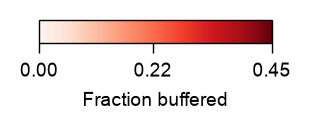

  Buffered: 0 – 0.45, cmap=Reds


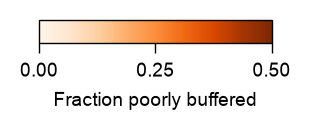

  Poorly buffered: 0 – 0.50, cmap=Oranges


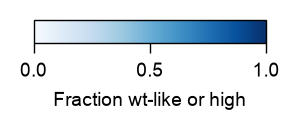

  WT-like or high: 0 – 1.00, cmap=Blues


In [50]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "svg.fonttype": "none",
})

for cls in BUFFERING_ORDER:
    col = f"frac_{cls.replace(' ', '_').replace('-', '_').lower()}"
    vmax = max(0.3, np.ceil(np.nanpercentile(consensus_aligned[col], 95) * 20) / 20)
    cmap_name = BUFFERING_CMAPS[cls]

    fig_cb, ax_cb = plt.subplots(figsize=(1.5, 0.15))
    sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap_name),
                                norm=plt.Normalize(0, vmax))
    sm.set_array([])
    cbar = fig_cb.colorbar(sm, cax=ax_cb, orientation="horizontal",
                           ticks=[0, round(vmax / 2, 2), vmax])
    cbar.set_label(f"Fraction {cls.lower()}", fontsize=7)
    cbar.ax.tick_params(labelsize=7)
    cbar.outline.set_linewidth(0.5)

    stem = FIG / f"fig4e_colorbar_{col}"
    save_figure(fig_cb, stem)
    plt.show()
    print(f"  {cls}: 0 – {vmax:.2f}, cmap={cmap_name}")

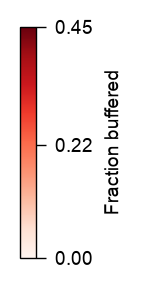

  Buffered: 0 – 0.45, cmap=Reds


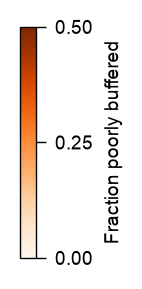

  Poorly buffered: 0 – 0.50, cmap=Oranges


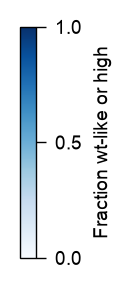

  WT-like or high: 0 – 1.00, cmap=Blues


In [51]:
for cls in BUFFERING_ORDER:
    col = f"frac_{cls.replace(' ', '_').replace('-', '_').lower()}"
    vmax = max(0.3, np.ceil(np.nanpercentile(consensus_aligned[col], 95) * 20) / 20)
    cmap_name = BUFFERING_CMAPS[cls]

    fig_cb, ax_cb = plt.subplots(figsize=(0.1, 1.5))
    sm = plt.cm.ScalarMappable(cmap=plt.get_cmap(cmap_name),
                                norm=plt.Normalize(0, vmax))
    sm.set_array([])
    cbar = fig_cb.colorbar(sm, cax=ax_cb, orientation="vertical",
                           ticks=[0, round(vmax / 2, 2), vmax])
    cbar.set_label(f"Fraction {cls.lower()}", fontsize=7)
    cbar.ax.tick_params(labelsize=7)
    cbar.outline.set_linewidth(0.5)

    stem = FIG / f"fig4e_colorbar_vertical_{col}"
    save_figure(fig_cb, stem)
    plt.show()
    print(f"  {cls}: 0 – {vmax:.2f}, cmap={cmap_name}")

## 4E comparison — the same alignment-column consensus on BRAF's and MEK1's own structures (exploratory)

In [38]:
def plot_structure(
    out_stem: str | Path,
    *,
    structure: str,
    query_chains: Sequence[str] = ("A",),
    sphere_counts: Mapping[int, float] | None = None,
    residue_values: Mapping[int, float] | None = None,
    sphere_color: tuple[float, float, float] | str = (0.75, 0.16, 0.16),
    cmap: str = "Reds",
    vmin: float = 0.0,
    vmax: float = 1.0,
    nodata_color: str = "gray35",
    radius_range: tuple[float, float] = (0.6, 3.5),
    count_range: tuple[float, float] = (1.0, 20.0),
    partners: Sequence[tuple[str, str, str] | Mapping] = (),
    ligands: Sequence[str] = (),
    graft: Mapping | None = None,
    ligand_color: str = "yellow",
    ion_vdw: float = 0.9,
    cartoon_color: str = STRUCT_CARTOON_COLOR,
    view: Sequence[float] | None = None,
    align_to: str | None = None,
    align_chain: str = "A",
    align_resi: tuple[int, int] | None = None,
    align_rotations: Sequence[tuple[str, float]] = (),
    px_per_angstrom: float = 14.0,
    pad_angstrom: float = 6.0,
    cartoon_pad_angstrom: float = 4.0,
    max_px: int = 3000,
    bg_color: str = "white",
    save_pse: bool = True,
    run: bool = True,
    extra_commands: Sequence[str] = (),
) -> Path:
    out_stem = Path(out_stem)
    out_stem.parent.mkdir(parents=True, exist_ok=True)
    pml = out_stem.with_suffix(".pml")
    obj = out_stem.name.upper().replace("-", "_").replace(".", "_")
    if str(structure).startswith("fetch:"):
        PYMOL_FETCH_CACHE.mkdir(parents=True, exist_ok=True)
        load = f"fetch {str(structure).split(':', 1)[1]}, {obj}, async=0"
    else:
        load = f"load {Path(structure).resolve()}, {obj}"
    q_sel = " or ".join(f"chain {c}" for c in query_chains)
    L = [f"# {out_stem.name}",
         f"set fetch_path, {PYMOL_FETCH_CACHE.resolve()}"]
    if align_to is not None:
        if str(align_to).startswith("fetch:"):
            L.append(f"fetch {str(align_to).split(':', 1)[1]}, _anchor_raw, async=0")
        else:
            L.append(f"load {Path(align_to).resolve()}, _anchor_raw")
        rng = f" and resi {align_resi[0]}-{align_resi[1]}" if align_resi else ""
        L += ["remove _anchor_raw and (solvent or hetatm)",
              f"create _pose_anchor, _anchor_raw and chain {align_chain} "
              f"and polymer{rng}",
              "delete _anchor_raw", "orient _pose_anchor"]
        for axis, angle in align_rotations:
            L.append(f"rotate {axis}, {angle}, _pose_anchor")
    L += [load, "remove solvent", "remove hydro", "hide everything",
          f"select query_sel, {obj} and ({q_sel})",
          "show cartoon, query_sel",
          f"color {cartoon_color}, query_sel"]
    if align_to is not None:
        # cealign gets within a few Angstrom; `super` refines it. cealign alone
        # leaves ~3 A RMSD, which visibly tilts the kinase.
        L += ["cealign _pose_anchor, query_sel",
              "super query_sel, _pose_anchor, cycles=5",
              "hide everything, _pose_anchor", "delete _pose_anchor"]
    if graft:
        g_src = str(graft["structure"])
        if g_src.startswith("fetch:"):
            L.append(f"fetch {g_src.split(':', 1)[1]}, _graft_raw, async=0")
        else:
            L.append(f"load {Path(g_src).resolve()}, _graft_raw")
        g_chain = graft.get("align_chain", "A")
        lo, hi = graft["align_resi"]
        L += ["remove _graft_raw and solvent",
              f"create _graft_ref, _graft_raw and chain {g_chain} and polymer "
              f"and resi {lo}-{hi}",
              f"align _graft_ref, {obj} and ({q_sel}) and resi {lo}-{hi}, "
              "cycles=5, object=_graft_aln",
              "python",
              "m = cmd.get_object_matrix('_graft_ref')",
              "cmd.transform_object('_graft_raw', m)",
              "python end",
              f"create graft_sel, _graft_raw and chain {graft['keep_chain']}",
              "delete _graft_ref", "delete _graft_aln", "delete _graft_raw",
              "hide everything, graft_sel",
              "show sticks, graft_sel",
              f"color {graft.get('color', 'yellow')}, graft_sel",
              "python",
              "from pymol import util",
              "util.cnc('graft_sel')",
              f"print('grafted {graft.get('label', 'ligand')}: %d atoms' % "
              "cmd.count_atoms('graft_sel'))",
              "python end"]
    partner_specs = []
    for i, rec in enumerate(partners):
        d = (dict(zip(("chain", "label", "color"), rec))
             if isinstance(rec, (tuple, list)) else dict(rec))
        safe = "".join(c if c.isalnum() or c in "._" else "_"
                       for c in str(d["label"]))
        d["sel"] = f"partner_{i}_{safe}"
        partner_specs.append(d)
        L += [f"select {d['sel']}, {obj} and chain {d['chain']}",
              f"color {d['color']}, {d['sel']}", "python",
              f"n_ca = cmd.count_atoms('{d['sel']} and name CA')",
              f"cmd.show('sticks' if n_ca <= 15 else 'cartoon', '{d['sel']}')",
              "python end"]
    if residue_values:
        cm, span = plt.get_cmap(cmap), (vmax - vmin) or 1.0
        L += [f"color {nodata_color}, query_sel",
              "set cartoon_smooth_loops, 0", "set cartoon_discrete_colors, 1"]
        by_colour: dict[tuple, list[int]] = {}
        for pos, val in residue_values.items():
            if val is None or not np.isfinite(val):
                continue
            rgb = tuple(round(c, 3) for c in
                        cm(min(max((val - vmin) / span, 0.0), 1.0))[:3])
            by_colour.setdefault(rgb, []).append(int(pos))
        for k, (rgb, positions) in enumerate(sorted(by_colour.items())):
            L += [f"set_color ramp_{k}, [{rgb[0]}, {rgb[1]}, {rgb[2]}]",
                  f"color ramp_{k}, {obj} and ({q_sel}) and resi "
                  + "+".join(str(x) for x in sorted(positions))]
    def _sphere_cmds(sel_expr: str, counts, colour, tag: str) -> list[str]:
        c0, c1 = count_range
        r0, r1 = radius_range
        out: list[str] = []
        if isinstance(colour, str):
            name = colour
        else:
            name = f"sphere_col_{tag}"
            out.append(f"set_color {name}, [{colour[0]:.3f}, "
                       f"{colour[1]:.3f}, {colour[2]:.3f}]")
        by_radius: dict[float, list[int]] = {}
        for pos, n in counts.items():
            if n is None or not np.isfinite(n) or n < c0:
                continue
            frac = (min(float(n), c1) - c0) / max(c1 - c0, 1e-9)
            by_radius.setdefault(round(r0 + frac * (r1 - r0), 3),
                                 []).append(int(pos))
        for radius, positions in sorted(by_radius.items()):
            out.append(f"alter (({sel_expr}) and resi "
                       + "+".join(str(x) for x in sorted(positions))
                       + f" and name CA), vdw={radius:.3f}")
        allp = sorted(x for ps in by_radius.values() for x in ps)
        if allp:
            out += ["rebuild",
                    f"select dn_spheres_{tag}, ({sel_expr}) and resi "
                    + "+".join(str(x) for x in allp) + " and name CA",
                    f"show spheres, dn_spheres_{tag}",
                    f"color {name}, dn_spheres_{tag}",
                    "python",
                    f"print('spheres {tag}: %d of {len(allp)} positions present "
                    f"in this structure' % cmd.count_atoms('dn_spheres_{tag}'))",
                    "python end"]
        return out
    partner_sphere_specs = [d for d in partner_specs if d.get("sphere_counts")]
    if sphere_counts or partner_sphere_specs:
        # Shrink every atom first, once, so only the residues given a radius
        # below render as spheres.
        L += ["alter all, vdw=0.01", "rebuild"]
        if sphere_counts:
            L += _sphere_cmds(f"{obj} and ({q_sel})", sphere_counts,
                              sphere_color, "query")
        for i, d in enumerate(partner_sphere_specs):
            L += _sphere_cmds(f"{obj} and chain {d['chain']}",
                              d["sphere_counts"],
                              d.get("sphere_color", sphere_color), f"p{i}")
    if ligands:
        # After the sphere pass, because that sets vdw=0.01 on every atom to
        # keep unmarked residues from rendering as spheres — the ions need their
        # radius restored afterwards or they vanish.
        resn = "+".join(str(r).upper() for r in ligands)
        L += [f"select ligand_sel, {obj} and ({q_sel}) and resn {resn}",
              "python",
              "from pymol import util",
              "cmd.show('sticks', 'ligand_sel and not (elem MG+ZN+CA+MN+NA+K+CL+FE)')",
              "cmd.show('spheres', 'ligand_sel and elem MG+ZN+CA+MN+NA+K+CL+FE')",
              f"cmd.alter('ligand_sel and elem MG+ZN+CA+MN+NA+K+CL+FE', 'vdw={ion_vdw}')",
              "cmd.rebuild()",
              f"cmd.color('{ligand_color}', 'ligand_sel')",
              # Non-carbon atoms back to element colours, so the phosphates and
              # ribose of a nucleotide stay legible instead of a yellow blob.
              "util.cnc('ligand_sel and not (elem MG+ZN+CA+MN+NA+K+CL+FE)')",
              "print('ligand atoms shown: %d' % cmd.count_atoms('ligand_sel'))",
              "python end",
              "set stick_radius, 0.20"]
    L += [f"bg_color {bg_color}", "set ray_shadows, 0", "set antialias, 2",
          "set ray_opaque_background, 1", "set sphere_quality, 4",
          "set cartoon_fancy_helices, 1", "set depth_cue, 0",
          "set specular, 0.25", "set orthoscopic, on", *extra_commands]
    png = out_stem.with_suffix(".png").resolve()
    # Everything that carries a sphere must be inside the frame, not just the
    # query chain — otherwise a partner's DNs would be cropped.
    framed = " or ".join([f"{obj} and ({q_sel})"]
                         + [f"{obj} and chain {d['chain']}"
                            for d in partner_specs]
                         + (["ligand_sel"] if ligands else [])
                         + (["graft_sel"] if graft else []))
    L.append(f"select framed_sel, {framed}")
    _fit = ["python",
            "import math",
            "v = list(cmd.get_view())",
            "fov = abs(v[17]) or 20.0",
            "R, org = v[0:9], v[12:15]",
            "P = cmd.get_coords('framed_sel')",
            "def _proj(k, off):",
            "    return [R[3 * k] * (q[0] - org[0]) + R[3 * k + 1] * (q[1] - org[1])"
            " + R[3 * k + 2] * (q[2] - org[2]) + off for q in P]",
            "xs, ys, zs = _proj(0, v[9]), _proj(1, v[10]), _proj(2, 0.0)",
            f"pad = {pad_angstrom} + {radius_range[1]} + {cartoon_pad_angstrom}",
            "half = lambda s: max(abs(min(s)), abs(max(s)))",
            "side = 2 * max(half(xs), half(ys)) + 2 * pad",
            "d = side / (2.0 * math.tan(math.radians(fov) / 2.0))",
            "v[11] = -d",
            "v[15] = max(1.0, d - half(zs) - pad)",
            "v[16] = d + half(zs) + pad",
            "cmd.set_view(v)",
            f"n = min(int(round(side * {px_per_angstrom})), {max_px})",
            "print('fit %.1f A square (pad %.1f) -> %d px (%.2f px/A)'"
            " % (side, pad, n, n / side))",
            f"cmd.png(r'{png}', width=n, height=n, dpi=300, ray=1)",
            "python end"]
    if view is not None:
        # A pinned view supplies the ORIENTATION and CENTRING; its zoom is
        # refit above so nothing is cropped.
        L += ["set_view (" + ", ".join(f"{v:.6f}" for v in view) + ")"] + _fit
    else:
        # No curated view: PyMOL's own principal-axes orientation, which is
        # reproducible but arbitrary. Same sizing rule from there.
        L += ["orient framed_sel"] + _fit
    if save_pse:
        L.append(f"save {out_stem.with_suffix('.pse').resolve()}")
    pml.write_text("\n".join(L) + "\n")
    if run:
        if not PYMOL_BIN.exists():
            raise FileNotFoundError(
                f"PyMOL not found at {PYMOL_BIN}. Set the PYMOL env var.")
        res = subprocess.run([str(PYMOL_BIN), "-cq", str(pml)],
                             capture_output=True, text=True, timeout=900)
        if res.returncode != 0:
            raise RuntimeError(f"PyMOL failed on {pml.name}:\n"
                               f"{res.stdout[-800:]}\n{res.stderr[-800:]}")
    return pml

# === VISUAL CONFIG ===
FONT_SIZES = {"axis": 8.0, "tick": 7.0, "legend": 7.0, "title": 9.0, "annot": 6.5}
LINE_WIDTHS = {"axes": 0.6, "plot": 1.2}
align_lut = pd.read_csv(ANNOTATED_COMBINED, sep="\t", low_memory=False,
                        usecols=["protein", "Position", "alignment_pos", "domain"])
align_lut = align_lut[align_lut.domain == "kinase"].drop_duplicates(["protein", "Position"])
align_lut["Position"] = pd.to_numeric(align_lut["Position"], errors="coerce")
kd_pos = kd.dropna(subset=["buffering_class"]).copy()
kd_pos["Position"] = pd.to_numeric(kd_pos["Position"], errors="coerce")
kd_al = kd_pos.merge(align_lut[["protein", "Position", "alignment_pos"]],
                     on=["protein", "Position"], how="left", validate="many_to_one")
print(f"{kd_al['alignment_pos'].isna().sum():,} of {len(kd_al):,} kinase-domain "
      "missense rows have no alignment_pos (edge/gap columns of the profiled "
      "alignment) and are dropped from this consensus")
kd_al = kd_al.dropna(subset=["alignment_pos"])
kd_al["alignment_pos"] = kd_al["alignment_pos"].astype(int)
FRAC_COLS = [f"frac_{c.replace(' ', '_').replace('-', '_').lower()}"
            for c in BUFFERING_ORDER]
per_align = (kd_al.groupby(["protein", "alignment_pos", "buffering_class"]).size()
            .unstack(fill_value=0))
per_align["n"] = per_align.sum(axis=1)
for cls, col in zip(BUFFERING_ORDER, FRAC_COLS):
    if cls not in per_align:
        per_align[cls] = 0
    per_align[col] = per_align[cls] / per_align["n"]
consensus_aligned = per_align.reset_index().groupby("alignment_pos")[FRAC_COLS].mean()
print(f"{len(consensus_aligned):,} alignment columns with >=1 profiled kinase "
      f"(vs {per_pos.shape[0]:,} per-(protein, native Position) QC rows above -- "
      "not a pooling comparison, both renders now use this same alignment-column "
      "consensus; see the markdown cell above)")
# Each target protein's own alignment_pos -> native Position map, so the
# consensus lands on ITS OWN numbering.
ALT_TARGETS = {"braf": {"chain": "B", "label": "BRAF"},
              "mek1": {"chain": "A", "label": "MEK1"}}
for prot, spec in ALT_TARGETS.items():
    p_lut = (align_lut[align_lut.protein == prot]
            .dropna(subset=["Position", "alignment_pos"])
            .assign(alignment_pos=lambda d: d.alignment_pos.astype(int))
            .drop_duplicates("alignment_pos")
            .set_index("alignment_pos")["Position"])
    for cls, col in zip(BUFFERING_ORDER, FRAC_COLS):
        vals = (consensus_aligned[col].rename("val").to_frame()
                .join(p_lut, how="inner").set_index("Position")["val"].to_dict())
        vmax = max(0.3, np.ceil(np.nanpercentile(consensus_aligned[col], 95) * 20) / 20)
        stem = FIG / f"fig4e_ALT_alignpos_4mne_{prot}_{col}"
        plot_structure(
            stem, structure="fetch:4MNE", query_chains=(spec["chain"],),
            residue_values=vals, cmap=BUFFERING_CMAPS[cls],
            vmin=0.0, vmax=vmax, nodata_color="gray35", run=RENDER_STRUCTURES)
        print(f"  {spec['label']:6s} {cls:16s} -> {stem.name}.png  "
              f"(vmax={vmax:.2f}) ({len(vals)} positions)")

1,174 of 44,905 kinase-domain missense rows have no alignment_pos (edge/gap columns of the profiled alignment) and are dropped from this consensus
349 alignment columns with >=1 profiled kinase (vs 2,503 per-(protein, native Position) QC rows above -- not a pooling comparison, both renders now use this same alignment-column consensus; see the markdown cell above)
  BRAF   Buffered         -> fig4e_ALT_alignpos_4mne_braf_frac_buffered.png  (vmax=0.45) (260 positions)
  BRAF   Poorly buffered  -> fig4e_ALT_alignpos_4mne_braf_frac_poorly_buffered.png  (vmax=0.50) (260 positions)
  BRAF   WT-like or high  -> fig4e_ALT_alignpos_4mne_braf_frac_wt_like_or_high.png  (vmax=1.00) (260 positions)
  MEK1   Buffered         -> fig4e_ALT_alignpos_4mne_mek1_frac_buffered.png  (vmax=0.45) (294 positions)
  MEK1   Poorly buffered  -> fig4e_ALT_alignpos_4mne_mek1_frac_poorly_buffered.png  (vmax=0.50) (294 positions)
  MEK1   WT-like or high  -> fig4e_ALT_alignpos_4mne_mek1_frac_wt_like_or_high.png  (vma

## 4F and S4C — what confers buffering

predictor coverage on the paired kinase-domain cohort:
  ddG_SPURS            100.0%
  relative_sasa        100.0%
  jsd_conservation      89.2%


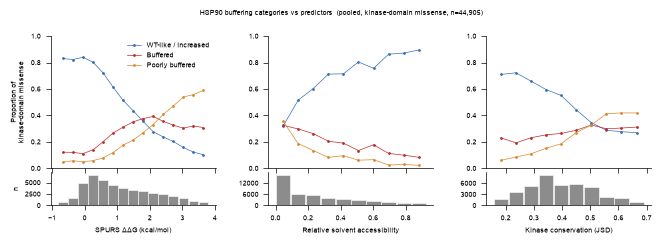

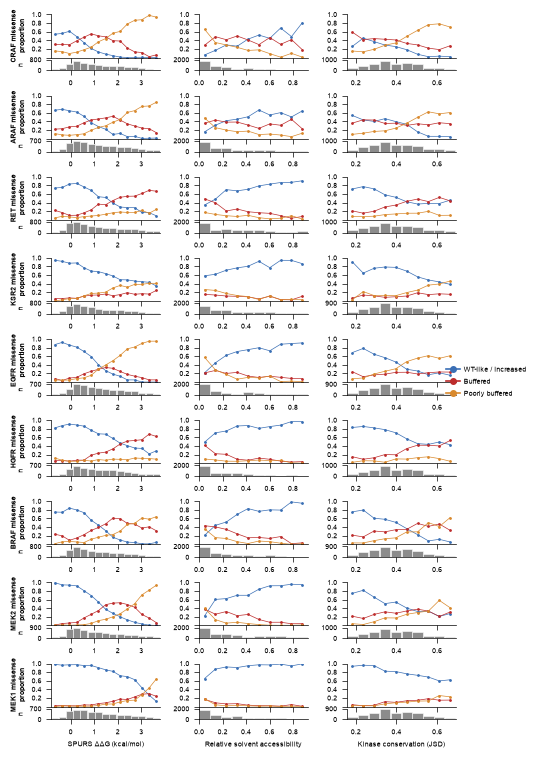

In [15]:
plt.rcParams.update({
    "font.size": 7, "axes.labelsize": 7, "axes.titlesize": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
    "legend.title_fontsize": 7,
    "axes.linewidth": 0.5, "xtick.major.width": 0.5, "ytick.major.width": 0.5,
    "lines.linewidth": 0.5, "patch.linewidth": 0.5,
    "figure.dpi": 100, "savefig.transparent": True,
    "svg.fonttype": "none",
})


def plot_univariate_profiles(
    profiles: Mapping[tuple, pd.DataFrame],
    edges: Mapping[str, Sequence[float]],
    *,
    predictors: Sequence[Mapping],
    categories: Sequence[tuple[str, str, str]],
    proteins: Sequence[str] = (),
    ylabel: str = "Proportion of\nkinase-domain missense",
    row_ylabel_fmt: str = "{label} missense\nproportion",
    suptitle: str = "",
    figsize: tuple[float, float] | None = None,
    fs: Mapping[str, float] | None = None,
) -> tuple[Figure, Axes]:
    from matplotlib.lines import Line2D
    import matplotlib.ticker as mticker

    F = {"axis": 17.0, "tick": 14.0, "hist_axis": 15.0, "hist_tick": 13.0,
         "legend": 16.0, "row": 15.0, "suptitle": 15.0}
    F.update(fs or {})

    per_protein = bool(len(proteins))
    rows = list(proteins) if per_protein else [None]
    n_rows, n_cols = len(rows), len(predictors)

    def _round_ceiling(v: float) -> int:
        if v <= 0:
            return 1
        mag = 10 ** int(np.floor(np.log10(v)))
        return int(np.ceil(v / mag) * mag)

    if per_protein:
        fs_default = figsize or (4.7 * n_cols, 2.5 * n_rows)
        fig = plt.figure(figsize=fs_default)
        outer = fig.add_gridspec(n_rows, n_cols, hspace=0.45, wspace=0.36,
                                 top=0.99, bottom=0.05, right=0.86)
    else:
        fs_default = figsize or (5.8 * n_cols, 6.4)
        fig = plt.figure(figsize=fs_default)
        outer = fig.add_gridspec(1, n_cols, wspace=0.32)

    fig.patch.set_alpha(0.0)

    first = None
    for r, prot in enumerate(rows):
        for c, pcfg in enumerate(predictors):
            prof = profiles.get((prot, pcfg["col"]))
            e = np.asarray(edges[pcfg["col"]], dtype=float)

            inner = outer[r, c].subgridspec(
                2, 1, height_ratios=[4, 1],
                hspace=0.08 if per_protein else 0.05)
            ax = fig.add_subplot(inner[0])
            ax_h = fig.add_subplot(inner[1], sharex=ax)
            ax.patch.set_alpha(0.0)
            ax_h.patch.set_alpha(0.0)
            first = first or ax

            if prof is None or prof.empty:
                ax.set_visible(False)
                ax_h.set_visible(False)
                continue

            # Profile lines
            for key, label, colour in categories:
                ax.plot(prof["bin_center"], prof[f"frac_{key}"], "-o",
                        color=colour, markersize=1, lw=0.5, label=label)

            ax.set_ylim(0.0, 1.0)

            if per_protein:
                ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
                ax.set_yticklabels(["", "0.2", "0.4", "0.6", "0.8", "1.0"])

            if c == 0:
                ax.set_ylabel(
                    row_ylabel_fmt.format(label=protein_label(prot))
                    if per_protein else ylabel,
                    fontsize=F["row"] if per_protein else F["axis"],
                    fontweight="bold" if per_protein else "normal")

            ax.tick_params(labelsize=F["tick"])
            for sp in ("top", "right"):
                ax.spines[sp].set_visible(False)

            if not per_protein and c == 0:
                ax.legend(loc="upper right", frameon=False, fontsize=F["legend"])

            plt.setp(ax.get_xticklabels(), visible=False)

            # Count histogram
            widths = np.diff(e)
            centers = prof["bin_center"].to_numpy()
            counts = prof["n"].to_numpy()
            bw = np.array([widths[int(np.searchsorted(e, x, side="right") - 1)]
                           for x in centers])

            ax_h.bar(centers, counts, width=bw * 0.95, color="0.55",
                     edgecolor="white", linewidth=0.4)

            last_row = (r == n_rows - 1)
            if last_row:
                ax_h.set_xlabel(pcfg["label"], fontsize=F["axis"])

            if c == 0:
                ax_h.set_ylabel("n", fontsize=F["hist_axis"])

            ax_h.tick_params(axis="y", labelsize=F["hist_tick"])
            ax_h.tick_params(axis="x", labelsize=F["tick"])
            for sp in ("top", "right"):
                ax_h.spines[sp].set_visible(False)

            if counts.size and per_protein:
                top = _round_ceiling(float(counts.max()))
                ax_h.set_ylim(0, top)
                ax_h.set_yticks([0, top])
            elif counts.size:
                ax_h.set_ylim(0, counts.max() * 1.10)
                ax_h.yaxis.set_major_locator(
                    mticker.MaxNLocator(nbins=3, integer=True))
            else:
                ax_h.set_ylim(0, 1)

            if per_protein:
                ax.set_xlim(e[0], e[-1])
                ax_h.set_xlim(e[0], e[-1])

    if per_protein:
        handles = [Line2D([0], [0], color=col, marker="o", markersize=4, lw=1.2,
                          label=lab) for _k, lab, col in categories]
        fig.legend(handles=handles, loc="center right", ncol=1,
                   bbox_to_anchor=(1.0, 0.5), frameon=False,
                   fontsize=F["legend"], labelspacing=0.8, handletextpad=0.5)

    if suptitle:
        fig.suptitle(suptitle, fontsize=F["suptitle"],
                     y=0.995 if per_protein else 1.00)

    return fig, first


# === CONFIG ===
FS = 5
FONT_SIZES = {"axis": FS, "tick": FS, "hist_axis": FS, "hist_tick": FS,
              "legend": FS, "row": FS, "suptitle": FS}

PREDICTORS = [
    {"col": "ddG_SPURS",        "label": "SPURS ΔΔG (kcal/mol)",         "n_bins": 15},
    {"col": "relative_sasa",    "label": "Relative solvent accessibility", "n_bins": 10},
    {"col": "jsd_conservation", "label": "Kinase conservation (JSD)",    "n_bins": 10},
]

CATEGORIES = [("wt_like",  "WT-like / increased",  BUFFERING_COLORS["WT-like or high"]),
              ("buffered", "Buffered",        BUFFERING_COLORS["Buffered"]),
              ("poor",     "Poorly buffered", BUFFERING_COLORS["Poorly buffered"])]

CLASS_KEY = {"WT-like or high": "wt_like", "Buffered": "buffered",
             "Poorly buffered": "poor"}

X_CLIP_PCT = (0.5, 99.5)

# Cohort
cohort = kd.dropna(subset=["buffering_class"]).copy()
cohort["cat"] = cohort.buffering_class.map(CLASS_KEY)

print("predictor coverage on the paired kinase-domain cohort:")
for pc in PREDICTORS:
    print(f"  {pc['col']:20s} {cohort[pc['col']].notna().mean():6.1%}")

EDGES = {pc["col"]: bin_edges(pc["col"], pc["n_bins"]) for pc in PREDICTORS}

# 4F — pooled
prof_global = {(None, pc["col"]): binned(cohort, pc["col"], EDGES[pc["col"]])
               for pc in PREDICTORS}

fig, _ = plot_univariate_profiles(
    prof_global, EDGES, predictors=PREDICTORS, categories=CATEGORIES,
    suptitle="HSP90 buffering categories vs predictors  "
             f"(pooled, kinase-domain missense, n={len(cohort):,})",
    figsize=(7.75, 2.2),
    fs=FONT_SIZES)

save_figure(fig, FIG / "5f_univariate_pooled", tight=False)
plt.show()

# S4C — per protein
PROTS = [p for p in HSP90_ORDER if p in set(cohort.protein)]
missing = sorted(set(cohort.protein) - set(PROTS))
assert not missing, f"proteins in the cohort but not in the tier order: {missing}"

prof_pp = {(p, pc["col"]): binned(cohort[cohort.protein == p], pc["col"],
                                  EDGES[pc["col"]])
           for p in PROTS for pc in PREDICTORS}

fig, _ = plot_univariate_profiles(
    prof_pp, EDGES, predictors=PREDICTORS, categories=CATEGORIES,
    proteins=PROTS,
    # suptitle="HSP90 buffering categories vs predictors  "
    #          "(per protein, kinase-domain missense)",
    figsize=(5.5, 7.5),
    fs=FONT_SIZES)

save_figure(fig, FIG / "ExtDataHSP908c_univariate_per_protein")
plt.show()

## 4G — buffering by activity class

In [61]:
def fixed_pitch_bar_axes(
    n_bars: int,
    *,
    pitch_in: float = 0.95,
    axes_h_in: float = 3.40,
    left_in: float = 0.95,
    right_in: float = 0.30,
    bottom_in: float = 1.15,
    top_in: float = 0.50,
    legend_in: float = 0.0,
) -> tuple[Figure, Axes]:
    data_w = n_bars * pitch_in
    fig_w = left_in + data_w + right_in + legend_in
    fig_h = bottom_in + axes_h_in + top_in
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = fig.add_axes([left_in / fig_w, bottom_in / fig_h,
                       data_w / fig_w, axes_h_in / fig_h])
    ax.set_xlim(-0.5, n_bars - 0.5)
    return fig, ax

def plot_stacked_vbar(
    props: pd.DataFrame,
    *,
    colors: Mapping[str, str],
    n_by_row: Mapping[str, int] | pd.Series | None = None,
    xtick_fmt: str = "{label}\n(n={n:,})",
    ylabel: str = "Proportion of missense variants",
    legend_title: str = "WT-relative category",
    annot_min: float = 0.05,
    annot_fmt: str = "{:.2f}",
    bar_width: float = 0.62,
    ylim: tuple[float, float] = (0.0, 1.02),
    show_legend: bool = True,
    yticks: Sequence[float] | None = None,
    pitch_in: float = 0.95,
    legend_in: float = 1.70,
    axes_h_in: float = 3.40,
    left_in: float = 0.95,
    right_in: float = 0.30,
    bottom_in: float = 1.15,
    top_in: float = 0.50,
    fs: Mapping[str, float] | None = None,
) -> tuple[Figure, Axes]:
    F = {"annot": 11.0, "xtick": 12.0, "ylabel": 13.0, "ytick": 11.0,
         "legend": 11.0, "legend_title": 12.0}
    F.update(fs or {})
    groups = list(props.index)
    fig, ax = fixed_pitch_bar_axes(len(groups), pitch_in=pitch_in,
                                   axes_h_in=axes_h_in, legend_in=legend_in,
                                   left_in=left_in, right_in=right_in,
                                   bottom_in=bottom_in, top_in=top_in)
    bottoms = np.zeros(len(groups))
    is_top_seg = props.columns[-1]
    for seg in props.columns:
        vals = props[seg].to_numpy(dtype=float)
        ax.bar(range(len(groups)), vals, bottom=bottoms, label=str(seg),
               color=colors[seg], width=bar_width, linewidth=0.6,
               edgecolor="white")
        for i, (v, b) in enumerate(zip(vals, bottoms)):
            if v >= annot_min:
                ax.text(i, b + v / 2, annot_fmt.format(v), ha="center",
                        va="center", fontsize=F["annot"], color="white",
                        fontweight="bold")
            elif seg == is_top_seg and v > 0:
                ax.text(i, b + v + 0.02, annot_fmt.format(v), ha="center",
                        va="bottom", fontsize=F["annot"], color=colors[seg],
                        fontweight="bold")
        bottoms += vals
    ax.set_xticks(range(len(groups)))
    if n_by_row is not None:
        ax.set_xticklabels([xtick_fmt.format(label=g, n=int(n_by_row[g]))
                            for g in groups], fontsize=F["xtick"])
    else:
        ax.set_xticklabels([str(g) for g in groups], fontsize=F["xtick"])
    ax.set_ylabel(ylabel, fontsize=F["ylabel"])
    ax.set_ylim(*ylim)
    ax.set_xlabel("")
    ax.tick_params(axis="y", labelsize=F["ytick"])
    if yticks is not None:
        ax.set_yticks(list(yticks))
    if show_legend:
        ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0),
                  fontsize=F["legend"], frameon=False, title=legend_title,
                  title_fontsize=F["legend_title"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    return fig, ax

# === VISUAL CONFIG ===
FONT_SIZES = {"axis": 8.0, "tick": 7.0, "legend": 7.0, "title": 9.0, "annot": 6.5}
LINE_WIDTHS = {"axes": 0.6, "plot": 1.2}
# =====================
act_base = pd.read_csv(
    ANNOTATED_COMBINED, sep="\t", low_memory=False,
    usecols=["protein", "library", "variant", "assay", "assay_treatment",
             "Mutation Type", "classification_2.5pct", "DN_EV"])
act_base = act_base[(act_base.assay == "activity")
                    & act_base.assay_treatment.isin(BASELINE_TREATMENTS)
                    & act_base["Mutation Type"].isin(["missense", "deletion"])]
act_base["activity_group"] = activity_group(act_base)
xg = kd_md.merge(act_base[["protein", "library", "variant", "activity_group"]],
              on=["protein", "library", "variant"], how="inner")
xg = xg.dropna(subset=["buffering_class", "activity_group"])
print(f"kinase-domain missense+deletion with both a buffering and an activity class: "
      f"{len(xg):,}")
ACTIVITY_CLASS_ORDER = ["DN", "Low", "WT-like", "High"]
ACTIVITY_DISPLAY = {"DN": "DN", "low": "Low", "wt-like": "WT-like",
                    "high": "High"}
xg["activity_class"] = xg.activity_group.map(ACTIVITY_DISPLAY)
unmapped = sorted(set(xg.activity_group.dropna()) - set(ACTIVITY_DISPLAY))
assert not unmapped, f"unmapped activity classes: {unmapped}"
comp = (xg.groupby(["activity_class", "buffering_class"]).size()
        .unstack(fill_value=0)
        .reindex(index=[g for g in ACTIVITY_CLASS_ORDER
                        if g in set(xg.activity_class)],
                 columns=BUFFERING_STACK_ORDER, fill_value=0))
n_comp = comp.sum(axis=1)
# Vertical bars on the same fixed physical pitch as 4C, so a bar in this panel
# is exactly as wide as a bar there and the two can be read side by side. No
# legend: the colour key comes from 4C.
fig, _ = plot_stacked_vbar(
    comp.div(n_comp, axis=0), colors=BUFFERING_COLORS,
    n_by_row=n_comp.astype(int), show_legend=False,
    yticks=[0, 0.25, 0.5, 0.75, 1.0],
    ylabel="Proportion of missense and deletion variants")
save_figure(fig, FIG / "fig4g_buffering_by_activity_class")
plt.show()
display((comp.div(n_comp, axis=0) * 100).round(1))

KeyError: ['activity_group']

## S4B — per-protein effect, ordered by importance

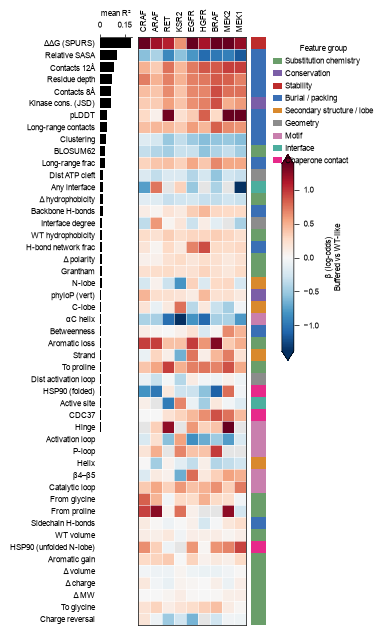

49 features x 9 proteins; colour = univariate beta for Buffered vs WT-like


In [20]:
def plot_beta_heatmap(
    betas: pd.DataFrame,
    importance: Mapping[str, float],
    *,
    col_order: Sequence[str],
    feature_labels: Mapping[str, str],
    feature_groups: Sequence[tuple[str, Sequence[tuple[str, str]]]],
    group_colors: Mapping[str, str],
    cell_in: float = 0.12,
    cbar_label: str = "β (log-odds)\nBuffered vs WT-like",
    imp_label: str = "mean R²",
    imp_ticks: tuple[float, float] = (0.0, 0.15),
    robust_pct: float = 98.0,
    fs: Mapping[str, float] | None = None,
) -> tuple[Figure, Axes]:
    import matplotlib.colors as _mc
    from matplotlib.colors import TwoSlopeNorm
    from matplotlib.patches import Patch
    F = {"feature": 6.0, "protein": 6.0, "imp_tick": 6, "imp_label": 6,
         "cbar": 6, "cbar_tick": 6, "legend": 6, "legend_title": 6}
    F.update(fs or {})
    group_of = {f: g for g, feats in feature_groups for f, _l in feats}
    present = set(betas["feature"])
    order = [f for f, _ in sorted(importance.items(), key=lambda kv: -kv[1])
             if f in present]
    r2 = [float(importance.get(f, 0.0)) for f in order]
    M = (betas.pivot_table(index="feature", columns="protein", values="coef")
         .reindex(index=order, columns=list(col_order)).to_numpy(dtype=float))
    vmax = float(np.nanpercentile(np.abs(M), robust_pct))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("0.9")
    n_row, n_col = len(order), len(col_order)
    s = cell_in
    left, xlab, top = 1.20, 0.12, 0.52
    bar_w, gap_b = 0.32, 0.06
    gap1, strip_w, gap2, cbar_w, right = 0.05, 0.15, 0.16, 0.12, 0.18
    data_w, data_h = n_col * s, n_row * s
    data_x = left + bar_w + gap_b
    fig_w = data_x + data_w + gap1 + strip_w + gap2 + cbar_w + right
    fig_h = xlab + data_h + top
    fig = plt.figure(figsize=(fig_w, fig_h))
    rect = lambda x, y, w, h: [x / fig_w, y / fig_h, w / fig_w, h / fig_h]
    y0 = xlab
    axb = fig.add_axes(rect(left, y0, bar_w, data_h))
    axb.barh(range(n_row), r2, color="black", height=0.8)
    axb.set_ylim(n_row - 0.5, -0.5)          # row 0 on top, matching imshow
    axb.set_yticks(range(n_row))
    axb.set_yticklabels([feature_labels.get(f, f) for f in order],
                        fontsize=F["feature"])
    axb.tick_params(length=0)
    axb.set_xlim(0, max(max(r2, default=imp_ticks[1]), imp_ticks[1]) * 1.03)
    axb.set_xticks(list(imp_ticks))
    axb.set_xticklabels([f"{v:g}" for v in imp_ticks])
    axb.xaxis.tick_top()
    axb.xaxis.set_label_position("top")
    axb.tick_params(axis="x", labelsize=F["imp_tick"], length=2)
    axb.set_xlabel(imp_label, fontsize=F["imp_label"])
    for sp in ("bottom", "right", "left"):
        axb.spines[sp].set_visible(False)
    ax = fig.add_axes(rect(data_x, y0, data_w, data_h))
    im = ax.imshow(np.ma.masked_invalid(M), aspect="auto", cmap=cmap, norm=norm)
    ax.set_xticks(range(n_col))
    ax.set_xticklabels(protein_labels(col_order), fontsize=F["protein"],
                       rotation=90)
    ax.xaxis.tick_top()
    ax.set_yticks([])                        # feature names live on the bars
    ax.tick_params(length=0)
    ax.set_xticks(np.arange(-0.5, n_col, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_row, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.4)
    ax.tick_params(which="minor", length=0)
    axg = fig.add_axes(rect(data_x + data_w + gap1, y0, strip_w, data_h))
    axg.imshow(np.array([[_mc.to_rgb(group_colors.get(group_of.get(f), "#999999"))]
                         for f in order]), aspect="auto")
    axg.set_xticks([])
    axg.set_yticks([])
    for sp in axg.spines.values():
        sp.set_visible(False)
    rx = data_x + data_w + gap1 + strip_w + gap2
    cax = fig.add_axes(rect(rx, y0 + data_h * 0.45, cbar_w, data_h * 0.35))
    cbar = fig.colorbar(im, cax=cax, extend="both")
    cbar.set_label(cbar_label, fontsize=F["cbar"])
    cbar.ax.tick_params(labelsize=F["cbar_tick"])
    groups_present = [g for g, _ in feature_groups
                      if any(group_of.get(f) == g for f in order)]
    fig.legend(handles=[Patch(facecolor=group_colors[g], label=g)
                        for g in groups_present],
               loc="upper left",
               bbox_to_anchor=((rx - gap2) / fig_w, (y0 + data_h) / fig_h),
               ncol=1, fontsize=F["legend"], frameon=False, handlelength=1.0,
               handletextpad=0.4, title="Feature group",
               title_fontsize=F["legend_title"])
    return fig, ax

# === VISUAL CONFIG ===
FONT_SIZES = {"axis": 8.0, "tick": 7.0, "legend": 7.0, "title": 9.0, "annot": 6.5}
LINE_WIDTHS = {"axes": 0.6, "plot": 1.2}
FA = OUTPUT / "hsp90" / "factor_analysis"
pp = pd.read_csv(FA / "buffering_factor_per_protein_importance.tsv", sep="\t")
betas = pp[pp.contrast == "buffered"]          # Buffered vs WT-like
# Feature order is by MEAN per-protein univariate pseudo-R², highest at top, so
# the rows are sorted by how much each feature actually explains. The contrast
# column duplicates each (protein, feature) pair, hence the dedupe.
mean_r2 = (pp.drop_duplicates(["protein", "feature"])
           .groupby("feature").pseudo_r2.mean().to_dict())
# Feature grouping and display names, from the factor-analysis feature spec
# (docs/hsp90_factor_features.md). Written out here so the figure does not
# depend on importing a plotting script.
FEATURE_GROUPS = [
    ("Substitution chemistry", [
        ("delta_hydrophobicity_z", "Δ hydrophobicity"), ("delta_volume_z", "Δ volume"),
        ("delta_charge_z", "Δ charge"), ("delta_polarity_z", "Δ polarity"),
        ("delta_mw_z", "Δ MW"), ("grantham_distance_z", "Grantham"),
        ("blosum62_score_z", "BLOSUM62"),
        ("wt_hydrophobicity_z", "WT hydrophobicity"), ("wt_volume_z", "WT volume"),
        ("to_proline", "To proline"), ("from_proline", "From proline"),
        ("to_glycine", "To glycine"), ("from_glycine", "From glycine"),
        ("charge_reversal", "Charge reversal"), ("aromatic_loss", "Aromatic loss"),
        ("aromatic_gain", "Aromatic gain")]),
    ("Conservation", [("jsd_conservation_z", "Kinase cons. (JSD)"),
                      ("phylop_vert_z", "phyloP (vert)")]),
    ("Stability", [("ddG_SPURS_z", "ΔΔG (SPURS)")]),
    ("Burial / packing", [
        ("relative_sasa_z", "Relative SASA"), ("plddt_z", "pLDDT"),
        ("contact_number_8A_z", "Contacts 8Å"), ("contact_number_12A_z", "Contacts 12Å"),
        ("depth_z", "Residue depth"), ("n_backbone_hbonds_z", "Backbone H-bonds"),
        ("n_sidechain_hbonds_z", "Sidechain H-bonds"),
        ("hbond_network_fraction_z", "H-bond network frac"),
        ("long_range_contacts_z", "Long-range contacts"),
        ("long_range_contact_fraction_z", "Long-range frac"),
        ("betweenness_centrality_z", "Betweenness"),
        ("clustering_coefficient_z", "Clustering")]),
    ("Secondary structure / lobe", [
        ("ss_helix", "Helix"), ("ss_strand", "Strand"),
        ("is_n_lobe", "N-lobe"), ("is_c_lobe", "C-lobe")]),
    ("Geometry", [("dist_to_atp_site_z", "Dist ATP cleft"),
                  ("dist_to_activation_loop_z", "Dist activation loop"),
                  ("n_partners_z", "Interface degree")]),
    ("Motif", [
        ("motif_gly_rich_loop", "P-loop"), ("motif_alphaC_helix", "αC helix"),
        ("motif_beta4_beta5", "β4–β5"), ("motif_hinge", "Hinge"),
        ("motif_DFG", "DFG"), ("motif_activation_loop", "Activation loop"),
        ("motif_catalytic_loop", "Catalytic loop")]),
    ("Interface", [
        ("active_site", "Active site"), ("interface_pdb_curated", "Protein interface"),
        ("at_any_chaperone_interface", "Chaperone interface"),
        ("at_any_interface", "Any interface")]),
    ("Chaperone contact", [
        ("at_hsp90_unfolded", "HSP90 (unfolded N-lobe)"),
        ("at_hsp90_folded", "HSP90 (folded)"), ("at_cdc37", "CDC37")]),
]
FEATURE_LABELS = {f: lab for _g, fs in FEATURE_GROUPS for f, lab in fs}
GROUP_COLORS = {"Substitution chemistry": "#6a9e6a", "Conservation": "#7b5ea7",
                "Stability": "#bd2c2c", "Burial / packing": "#3a6fb5",
                "Secondary structure / lobe": "#d9892d", "Geometry": "#8c8c8c",
                "Motif": "#c97fae", "Interface": "#4cae9e",
                "Chaperone contact": "#e7298a"}
unlabelled = sorted(set(betas.feature) - set(FEATURE_LABELS))
assert not unlabelled, f"features fitted but not in the spec: {unlabelled}"
# Same figure-4 ordering as 4D/S4A/S4C.
PROTS_S4B = [p for p in HSP90_ORDER if p in set(betas.protein)]
dropped = sorted(set(betas.protein) - set(PROTS_S4B))
assert not dropped, f"proteins fitted but not plotted: {dropped}"
fig, _ = plot_beta_heatmap(
    betas, mean_r2, col_order=PROTS_S4B, feature_labels=FEATURE_LABELS,
    feature_groups=FEATURE_GROUPS, group_colors=GROUP_COLORS)
save_figure(fig, FIG / "ExtDataHSP908b_per_protein_univariate_r2")
plt.show()
print(f"{len(set(betas.feature))} features x {len(PROTS_S4B)} proteins; "
      f"colour = univariate beta for Buffered vs WT-like")

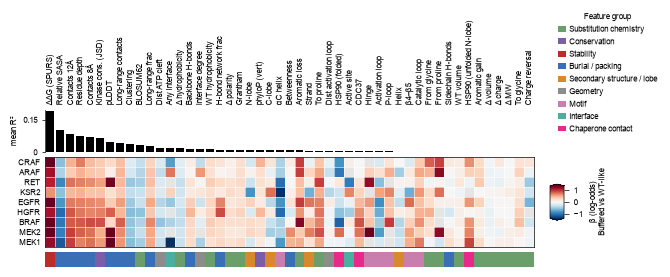

In [22]:
def plot_beta_heatmap_horizontal(
    betas: pd.DataFrame,
    importance: Mapping[str, float],
    *,
    row_order: Sequence[str],
    feature_labels: Mapping[str, str],
    feature_groups: Sequence[tuple[str, Sequence[tuple[str, str]]]],
    group_colors: Mapping[str, str],
    fig_width: float = 7.5,
    cbar_label: str = "β (log-odds)\nBuffered vs WT-like",
    imp_label: str = "mean R²",
    imp_ticks: tuple[float, float] = (0.0, 0.15),
    robust_pct: float = 98.0,
    fs: Mapping[str, float] | None = None,
    left: float = 1.0,
    top_label_h: float = 1.05,
    bar_h: float = 0.42,
) -> tuple[Figure, Axes]:
    """Transposed version of plot_beta_heatmap: proteins run down the rows,
    features run across the columns, and the per-feature importance bars sit
    on top (doubling as the column-label axis). Total figure width is fixed
    at `fig_width`; the cell size is derived to fit that width, so the figure
    grows taller (not wider) as more proteins are added.

    `left`, `top_label_h`, and `bar_h` are the three margins most likely to
    need tuning for your actual label text — bump `left` if protein names
    get clipped, `top_label_h` if the rotated feature names get clipped, and
    `right`/`bottom` (below) if the legend or colorbar crowd each other.
    """
    import matplotlib.colors as _mc
    from matplotlib.colors import TwoSlopeNorm
    from matplotlib.patches import Patch

    F = {"feature": 6.0, "protein": 6.0, "imp_tick": 6, "imp_label": 6,
         "cbar": 6, "cbar_tick": 6, "legend": 6, "legend_title": 6}
    F.update(fs or {})

    group_of = {f: g for g, feats in feature_groups for f, _l in feats}
    present = set(betas["feature"])
    order = [f for f, _ in sorted(importance.items(), key=lambda kv: -kv[1])
             if f in present]                       # column order, highest R^2 first
    r2 = [float(importance.get(f, 0.0)) for f in order]

    M = (betas.pivot_table(index="protein", columns="feature", values="coef")
         .reindex(index=list(row_order), columns=order).to_numpy(dtype=float))
    vmax = float(np.nanpercentile(np.abs(M), robust_pct))
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad("0.9")

    n_row, n_col = len(row_order), len(order)

    # --- geometry: width is fixed, cell size is derived from it ---
    gap_b, gap1, gap2 = 0.05, 0.05, 0.16
    strip_h, cbar_w, right, bottom = 0.15, 0.14, 1.45, 0.06
    data_w = fig_width - left - gap2 - right
    s = data_w / n_col                                # square-ish cells
    data_h = n_row * s
    fig_h = top_label_h + bar_h + gap_b + data_h + gap1 + strip_h + bottom
    fig_w = fig_width

    fig = plt.figure(figsize=(fig_w, fig_h))
    rect = lambda x, y, w, h: [x / fig_w, y / fig_h, w / fig_w, h / fig_h]

    # y-coordinates, measured from the bottom of the figure
    y_strip = bottom
    y_data = y_strip + strip_h + gap1
    y_bar = y_data + data_h + gap_b

    # importance bars (top), doubling as the column-label axis
    axt = fig.add_axes(rect(left, y_bar, data_w, bar_h))
    axt.bar(range(n_col), r2, color="black", width=0.8)
    axt.set_xlim(-0.5, n_col - 0.5)
    axt.set_xticks(range(n_col))
    axt.set_xticklabels([feature_labels.get(f, f) for f in order],
                        fontsize=F["feature"], rotation=90)
    axt.xaxis.tick_top()
    axt.tick_params(axis="x", length=0)
    ymax = max(max(r2, default=imp_ticks[1]), imp_ticks[1]) * 1.03
    axt.set_ylim(0, ymax)
    axt.set_yticks(list(imp_ticks))
    axt.set_yticklabels([f"{v:g}" for v in imp_ticks])
    axt.tick_params(axis="y", labelsize=F["imp_tick"], length=2)
    axt.set_ylabel(imp_label, fontsize=F["imp_label"])
    for sp in ("top", "right", "bottom"):
        axt.spines[sp].set_visible(False)

    # main heatmap
    ax = fig.add_axes(rect(left, y_data, data_w, data_h))
    im = ax.imshow(np.ma.masked_invalid(M), aspect="auto", cmap=cmap, norm=norm)
    ax.set_yticks(range(n_row))
    ax.set_yticklabels(protein_labels(list(row_order)), fontsize=F["protein"])
    ax.set_xticks([])                      # feature names live on the bars above
    ax.tick_params(length=0)
    ax.set_xticks(np.arange(-0.5, n_col, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_row, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.4)
    ax.tick_params(which="minor", length=0)

    # feature-group strip, below the heatmap
    axg = fig.add_axes(rect(left, y_strip, data_w, strip_h))
    axg.imshow(np.array([[_mc.to_rgb(group_colors.get(group_of.get(f), "#999999"))
                          for f in order]]), aspect="auto")
    axg.set_xticks([])
    axg.set_yticks([])
    for sp in axg.spines.values():
        sp.set_visible(False)

    # colorbar + legend, stacked in the reserved right margin
    rx = left + data_w + gap2
    cax = fig.add_axes(rect(rx, y_data + data_h * 0.3, cbar_w, data_h * 0.4))
    cbar = fig.colorbar(im, cax=cax, extend="both")
    cbar.set_label(cbar_label, fontsize=F["cbar"])
    cbar.ax.tick_params(labelsize=F["cbar_tick"])

    groups_present = [g for g, _ in feature_groups
                      if any(group_of.get(f) == g for f in order)]
    fig.legend(handles=[Patch(facecolor=group_colors[g], label=g)
                        for g in groups_present],
               loc="upper left",
               bbox_to_anchor=(rx / fig_w, 1.0),
               ncol=1, fontsize=F["legend"], frameon=False, handlelength=1.0,
               handletextpad=0.4, title="Feature group",
               title_fontsize=F["legend_title"])
    return fig, ax


# === usage (same setup as the vertical version) ===
fig, _ = plot_beta_heatmap_horizontal(
    betas, mean_r2, row_order=PROTS_S4B, feature_labels=FEATURE_LABELS,
    feature_groups=FEATURE_GROUPS, group_colors=GROUP_COLORS)
save_figure(fig, FIG / "ExtDataHSP908b_per_protein_univariate_r2_horizontal")
plt.show()

# Statistical analysis of dependence (different definition than used in paper)

In [6]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd

REPLICATE_COLS = [
    "intercept_0_std_adj_score_1",
    "intercept_0_std_adj_score_2",
    "intercept_0_std_adj_score_3",
]
BASELINE_TREATMENTS = {"No_treatment", "DMSO"}
ALPHA = 0.05  # significance threshold; adjust as needed

def classify_dependent_statistical(
    df,
    *,
    proteins=None,
    assay="abundance",
    mutation_types=("missense", "deletion"),
    alpha=ALPHA,
    min_reps=2,
):
    """
    For each (protein, library, variant), compare the replicate scores
    under HSP90i vs DMSO/No_treatment using a one-sided Welch t-test
    (H_a: HSP90i mean < control mean).

    Returns a DataFrame with one row per variant and columns:
      protein, library, variant, ctrl_mean, hsp90i_mean,
      t_stat, p_value, dependent
    """
    sub = df[
        (df.assay == assay)
        & df["Mutation Type"].isin(mutation_types)
    ].copy()
    if proteins is not None:
        sub = sub[sub.protein.isin(set(proteins))]

    # Split into control and HSP90i
    ctrl = sub[sub.assay_treatment.isin(BASELINE_TREATMENTS)]
    hsp  = sub[sub.assay_treatment == "HSP90i"]

    # For control, prefer DMSO over No_treatment when both exist
    ctrl = ctrl.copy()
    ctrl["_pref"] = (ctrl.assay_treatment == "DMSO").astype(int)
    ctrl = (ctrl.sort_values("_pref", ascending=False)
            .drop_duplicates(["protein", "library", "variant"])
            .drop(columns="_pref"))

    key = ["protein", "library", "variant"]
    merged = ctrl[key + REPLICATE_COLS].merge(
        hsp[key + REPLICATE_COLS],
        on=key,
        suffixes=("_ctrl", "_hsp"),
    )

    ctrl_cols = [f"{c}_ctrl" for c in REPLICATE_COLS]
    hsp_cols  = [f"{c}_hsp"  for c in REPLICATE_COLS]

    records = []
    for row in merged.itertuples(index=False):
        ctrl_vals = np.array([getattr(row, c) for c in ctrl_cols], dtype=float)
        hsp_vals  = np.array([getattr(row, c) for c in hsp_cols],  dtype=float)

        # Drop NaNs
        ctrl_vals = ctrl_vals[np.isfinite(ctrl_vals)]
        hsp_vals  = hsp_vals[np.isfinite(hsp_vals)]

        if len(ctrl_vals) < min_reps or len(hsp_vals) < min_reps:
            continue

        # One-sided Welch t-test: is HSP90i mean < control mean?
        t_stat, p_two = ttest_ind(hsp_vals, ctrl_vals, equal_var=False)
        # Convert to one-sided p-value (lower tail)
        p_one = p_two / 2 if t_stat < 0 else 1.0 - p_two / 2

        records.append({
            "protein":     row.protein,
            "library":     row.library,
            "variant":     row.variant,
            "ctrl_mean":   ctrl_vals.mean(),
            "hsp90i_mean": hsp_vals.mean(),
            "ctrl_reps":   len(ctrl_vals),
            "hsp90i_reps": len(hsp_vals),
            "t_stat":      t_stat,
            "p_value":     p_one,
        })

    result = pd.DataFrame(records)
    result["dependent"] = result.p_value < alpha
    return result


# --- Usage ---
dep = classify_dependent_statistical(
    Replicate_scores,
    proteins=HSP90I_PROTEINS,
    assay="abundance",
    mutation_types=("missense", "deletion"),
    alpha=0.05,
)

print(f"{len(dep):,} variants tested")
print(f"{dep.dependent.sum():,} classified as dependent "
      f"({dep.dependent.mean():.1%})")
print()
print(dep.groupby("protein")["dependent"]
      .agg(n="size", n_dep="sum", frac=lambda s: f"{s.mean():.1%}"))

96,038 variants tested
58,503 classified as dependent (60.9%)

             n  n_dep   frac
protein                     
araf     11339  11314  99.8%
braf     13706   7508  54.8%
craf     12373  12326  99.6%
egfr      9268   7717  83.3%
ksr2      9111   6044  66.3%
mek1      7217    610   8.5%
mek2      7650   2536  33.2%
met       8595   1554  18.1%
ret       8959   8652  96.6%
sos2      7820    242   3.1%


# Alternative 4A/S4a using a statistical definition of dependent

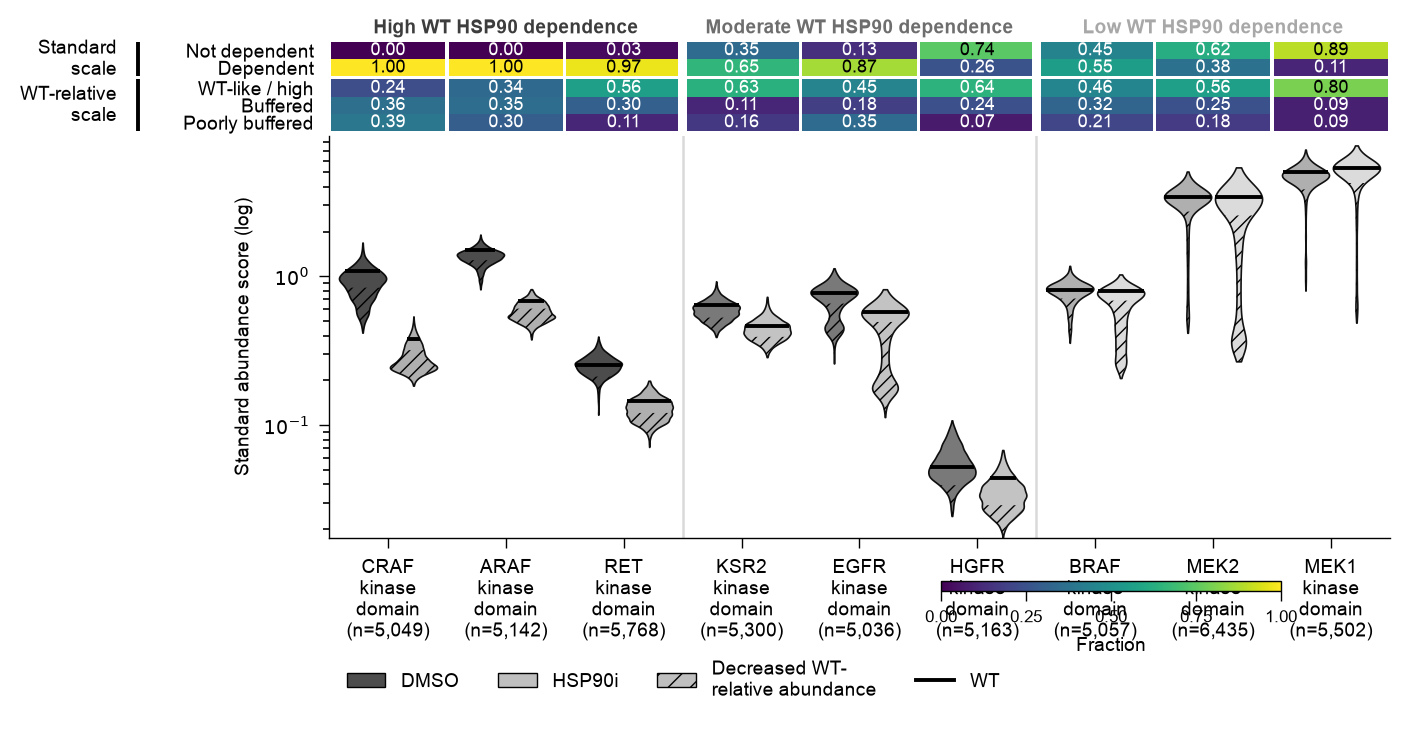

4D heatmap (statistical dependence):


,not_dependent,dependent,wt_like,buffered,poorly_buffered
craf,0.002,0.998,0.235,0.363,0.395
araf,0.001,0.999,0.337,0.353,0.296
ret,0.030,0.970,0.561,0.305,0.109
ksr2,0.347,0.653,0.634,0.108,0.163
egfr,0.134,0.866,0.453,0.185,0.346
met,0.743,0.257,0.644,0.244,0.071
braf,0.448,0.552,0.457,0.321,0.208
mek2,0.623,0.377,0.559,0.247,0.175
mek1,0.895,0.105,0.799,0.089,0.087



KeyboardInterrupt



KeyboardInterrupt: 

In [13]:
from scipy.stats import ttest_ind

# ---------------------------------------------------------------------------
# Replicate columns must be present in the working frame.
# If Replicate_scores doesn't already have them, reload with them included.
# ---------------------------------------------------------------------------
REPLICATE_COLS = [
    "intercept_0_std_adj_score_1",
    "intercept_0_std_adj_score_2",
    "intercept_0_std_adj_score_3",
]

# Verify the columns exist; if not, reload from the annotated TSV
for rc in REPLICATE_COLS:
    if rc not in Replicate_scores.columns:
        print(f"Column {rc} not found — reloading with replicate columns")
        _extra = pd.read_csv(
            ANNOTATED_COMBINED, sep="\t", low_memory=False,
            usecols=["protein", "library", "variant", "assay",
                     "assay_treatment"] + REPLICATE_COLS,
        )
        Replicate_scores = Replicate_scores.merge(
            _extra.drop_duplicates(["protein", "library", "variant",
                                    "assay", "assay_treatment"]),
            on=["protein", "library", "variant", "assay", "assay_treatment"],
            how="left",
        )
        del _extra
        break

# Rebuild abs_mf with the replicate columns included
abs_mf = Replicate_scores[
    (Replicate_scores.assay == "abundance")
    & Replicate_scores.assay_treatment.isin(["DMSO", "No_treatment", "HSP90i"])
].copy()
abs_mf["tx"] = np.where(abs_mf.assay_treatment == "HSP90i", "hsp90i", "ctrl")


# ---------------------------------------------------------------------------
# Modified violin_inputs: statistical dependence via per-variant t-test
# ---------------------------------------------------------------------------
DEP_ALPHA = 0.05  # significance threshold for one-sided t-test

def violin_inputs(proteins, *, kinase_only: bool, alpha=DEP_ALPHA):
    miss = abs_mf[abs_mf["Mutation Type"].isin(["missense", "deletion"])]
    if kinase_only:
        miss = miss[miss.domain == "kinase"]
    syn = abs_mf[abs_mf["Mutation Type"] == "synonymous wild type"]
    wt_rows = abs_mf[abs_mf["Mutation Type"] == "wild type"]

    arrays, wt, thresholds, heat = {}, {}, {}, {}

    for p in proteins:
        mp = miss[miss.protein == p]
        libs = ([mp.library.mode().iloc[0]] if kinase_only and len(mp)
                else sorted(abs_mf.loc[abs_mf.protein == p, "library"].unique()))

        # --- violin arrays, WT lines, low-score thresholds (unchanged) ---
        for tx in ("ctrl", "hsp90i"):
            s = mp[(mp.tx == tx) & mp.library.isin(libs)][SCORE_ABS].dropna()
            arrays[(p, tx)] = np.clip(s.to_numpy(dtype=float), 0.01, None)

            w = wt_rows[(wt_rows.protein == p) & (wt_rows.tx == tx)
                        & wt_rows.library.isin(libs)][SCORE_ABS]
            wt[(p, tx)] = float(w.mean()) if len(w) else np.nan

            sy = syn[(syn.protein == p) & (syn.tx == tx)
                     & syn.library.isin(libs)][SCORE_ABS].dropna()
            thresholds[(p, tx)] = (float(np.percentile(sy.to_numpy(), 2.5))
                                   if len(sy) else np.nan)

        # --- pair ctrl/hsp90i within library for heatmap fractions ----------
        parts = []
        for lib in libs:
            sl = mp[mp.library == lib]
            c = sl[sl.tx == "ctrl"][
                ["variant", SCORE_ABS, "classification_2.5pct"] + REPLICATE_COLS
            ].rename(columns={
                SCORE_ABS: "s_c", "classification_2.5pct": "cl_c",
                **{rc: f"{rc}_ctrl" for rc in REPLICATE_COLS},
            })
            h = sl[sl.tx == "hsp90i"][
                ["variant", SCORE_ABS, "classification_2.5pct"] + REPLICATE_COLS
            ].rename(columns={
                SCORE_ABS: "s_h", "classification_2.5pct": "cl_h",
                **{rc: f"{rc}_hsp" for rc in REPLICATE_COLS},
            })
            m = c.merge(h, on="variant")
            if len(m):
                parts.append(m)

        if not parts:
            heat[p] = {k: np.nan for k in HEATMAP_KEYS} | {"_n": 0}
            continue

        m = pd.concat(parts, ignore_index=True)
        n = len(m)

        # ===================================================================
        # NEW: statistical dependence — one-sided Welch t-test per variant
        # H_a: HSP90i mean < control mean  (i.e. abundance drops)
        # ===================================================================
        ctrl_rep_cols = [f"{rc}_ctrl" for rc in REPLICATE_COLS]
        hsp_rep_cols  = [f"{rc}_hsp"  for rc in REPLICATE_COLS]

        dep_flags = np.zeros(n, dtype=bool)
        for i in range(n):
            ctrl_vals = m.iloc[i][ctrl_rep_cols].to_numpy(dtype=float)
            hsp_vals  = m.iloc[i][hsp_rep_cols].to_numpy(dtype=float)

            ctrl_vals = ctrl_vals[np.isfinite(ctrl_vals)]
            hsp_vals  = hsp_vals[np.isfinite(hsp_vals)]

            if len(ctrl_vals) < 2 or len(hsp_vals) < 2:
                continue  # not enough replicates — stays False

            t_stat, p_two = ttest_ind(hsp_vals, ctrl_vals, equal_var=False)
            p_one = p_two / 2 if t_stat < 0 else 1.0 - p_two / 2
            dep_flags[i] = p_one < alpha

        dep = float(dep_flags.sum() / n)

        # --- buffering fractions (unchanged) --------------------------------
        c_nl, h_nl = m.cl_c.isin(NOTLOW), m.cl_h.isin(NOTLOW)
        c_lo, h_lo = m.cl_c == "low", m.cl_h == "low"

        heat[p] = {
            "not_dependent": 1.0 - dep, "dependent": dep,
            "wt_like": float((c_nl & h_nl).sum() / n),
            "buffered": float((c_nl & h_lo).sum() / n),
            "poorly_buffered": float((c_lo & h_lo).sum() / n),
            "_n": n,
        }

    return arrays, wt, thresholds, heat


# ---------------------------------------------------------------------------
# 4D — kinase-domain missense and deletion  (same call as before)
# ---------------------------------------------------------------------------
TRIM = (0.25, 99.75)

a, w, th, hm = violin_inputs(
    [p for _, ps in DEP_GROUPS_KD for p in ps], kinase_only=True)

fig, _, _ = plot_paired_score_violins(
    a, w, th, hm, groups=DEP_GROUPS_KD, group_fill=GROUP_FILL,
    heatmap_rows=HEATMAP_KEYS, heatmap_labels=HEATMAP_LABELS,
    figsize=(6.8, 3.1), height_ratios=(1.0, 4.5), trim_pct=TRIM,
    xtick_fmt="{label}\nkinase\ndomain\n(n={n:,})", legend_y=-0.45,
    fs={"axis": 7.0, "xtick": 7.0, "ytick": 7.0, "ylabel": 7.0,
        "cell": 6.5, "row": 7.0, "bracket": 7.0, "group": 7,
        "legend": 7.0})

save_figure(fig, FIG / "fig4d_kinase_domain_violins_stat_dep")
plt.show()

print("4D heatmap (statistical dependence):")
display(pd.DataFrame(hm).T[list(HEATMAP_KEYS)].round(3))


# ---------------------------------------------------------------------------
# S4A — all missense and deletion  (same call as before)
# ---------------------------------------------------------------------------
a2, w2, th2, hm2 = violin_inputs(
    [p for _, ps in DEP_GROUPS_ALL for p in ps], kinase_only=False)

fig, _, _ = plot_paired_score_violins(
    a2, w2, th2, hm2, groups=DEP_GROUPS_ALL, group_fill=GROUP_FILL,
    heatmap_rows=HEATMAP_KEYS, heatmap_labels=HEATMAP_LABELS,
    figsize=(6.8, 3.1), height_ratios=(1.0, 4.5), trim_pct=TRIM,
    xtick_fmt="{label}\n(n={n:,})", legend_y=-0.45,
    low_legend_label="Decreased WT-\nrelative abundance",
    ylabel="Standard abundance score (log)",
    fs={"axis": 7.0, "xtick": 7.0, "ytick": 7.0, "ylabel": 7.0,
        "cell": 6.5, "row": 7.0, "bracket": 7.0, "group": 7,
        "legend": 7.0})

save_figure(fig, FIG / "figsEDa_all_missense_violins_stat_dep")
plt.show()

print("\nS4A heatmap (statistical dependence):")
display(pd.DataFrame(hm2).T[list(HEATMAP_KEYS)].round(3))

## Export buffering and dependent annotations for table

In [7]:
# ===========================================================================
# Export HSP90i buffering/dependence annotations for merging into the main table
# ===========================================================================
# One row per (protein, library, variant) with:
#   - buffering_class       : threshold-based 3-way call ("Buffered" /
#                              "Poorly buffered" / "WT-like or high") — the
#                              definition used in the paper's figures
#   - dependent_threshold    : bool, HSP90i abundance score falls below the
#                              synonymous-WT-derived noise threshold
#   - dependent_significant  : bool, one-sided Welch t-test on per-replicate
#                              scores (HSP90i < ctrl), p<0.05 — the notebook's
#                              alternative statistical definition, NOT what's
#                              used in the paper figures

# ---------------------------------------------------------------------------
# 1) Threshold-based buffering / dependence (reuses pair_abundance,
#    syn_wt_low_threshold, assign_buffering already defined earlier in this
#    notebook)
# ---------------------------------------------------------------------------

paired = pair_abundance(Replicate_scores, SCORE_ABS, proteins=tuple(HSP90I_PROTEINS))
paired = assign_buffering(paired, Replicate_scores, SCORE_ABS)
paired["dependent_threshold"] = paired["hsp90i_score"] < paired["hsp90i_threshold"]

threshold_calls = paired[
    ["protein", "library", "variant", "buffering_class", "dependent_threshold"]
].drop_duplicates(["protein", "library", "variant"])

print(f"threshold-based calls: {len(threshold_calls):,} variants")

# ---------------------------------------------------------------------------
# 2) Statistical (t-test) dependence call
# ---------------------------------------------------------------------------

stat_calls = classify_dependent_statistical(
    Replicate_scores, proteins=HSP90I_PROTEINS,
    mutation_types=("missense", "deletion"),
)[["protein", "library", "variant", "dependent"]].rename(
    columns={"dependent": "dependent_significant"}
)

print(f"statistical calls: {len(stat_calls):,} variants")

# ---------------------------------------------------------------------------
# 3) Merge and export
# ---------------------------------------------------------------------------

hsp90_annotations = threshold_calls.merge(
    stat_calls, on=["protein", "library", "variant"], how="outer"
)

print(f"combined table: {len(hsp90_annotations):,} rows")
print(hsp90_annotations.columns.tolist())

OUT_PATH = "hsp90_derived_annotations.tsv"
hsp90_annotations.to_csv(OUT_PATH, sep="\t", index=False)
print(f"wrote {OUT_PATH}")

threshold-based calls: 110,360 variants
statistical calls: 96,038 variants
combined table: 110,360 rows
['protein', 'library', 'variant', 'buffering_class', 'dependent_threshold', 'dependent_significant']
wrote hsp90_derived_annotations.tsv
